DATA LOADED
Rows before filtering: 55000
Columns: 14

DATA AFTER FILTERING COMPETITOR ROWS
Rows after removing EW: 41416
Week range: 1 to 52

Leakage feature check passed.
All required model features exist.

TIME SPLIT
Train weeks : W01 to W41
Test weeks  : W42 to W52
Train rows  : 32638
Test rows   : 8778

FINAL POINT MODEL ON FULL TRAIN

Test: Current Log RF
------------------------------------------------------------
MAE  : 15.8115
RMSE : 21.9446
R2   : 0.7746

Test: Holt + Residual RF
------------------------------------------------------------
MAE  : 11.0282
RMSE : 16.8334
R2   : 0.8674

Test: Fixed Weighted Ensemble
------------------------------------------------------------
MAE  : 10.6057
RMSE : 16.1395
R2   : 0.8781

POINT MODEL FINAL TEST COMPARISON
                        Model       MAE      RMSE       R2
Test: Fixed Weighted Ensemble 10.605744 16.139453 0.878084
     Test: Holt + Residual RF 11.028248 16.833375 0.867375
         Test: Current Log RF 15.811514 21.944625 0.7

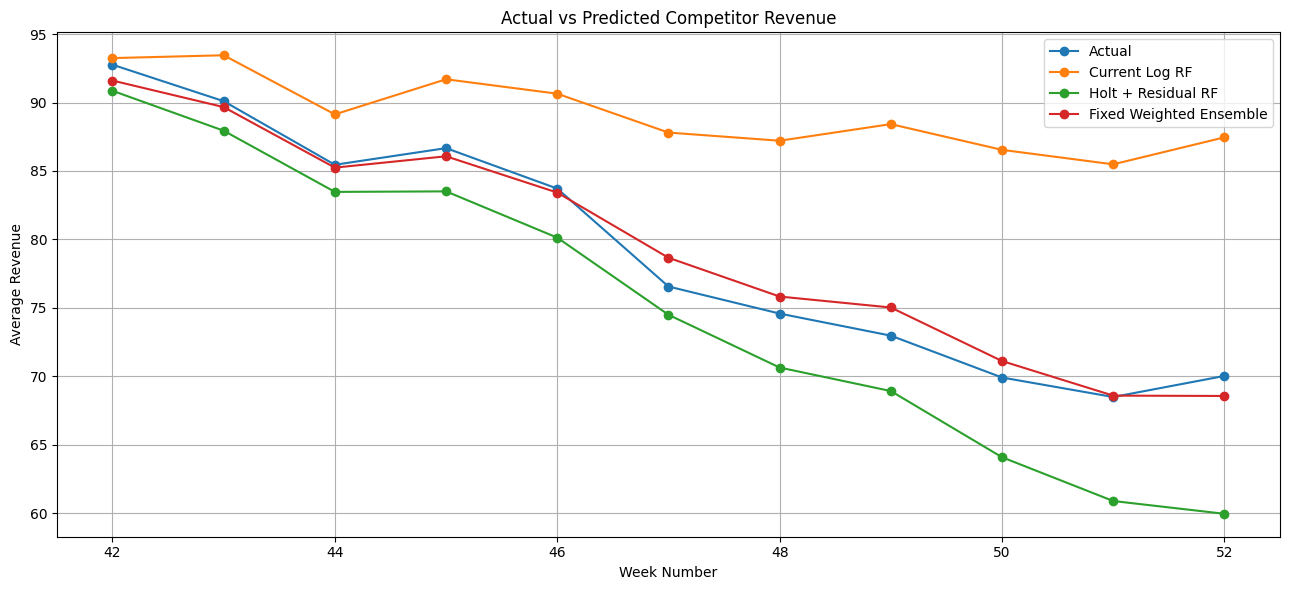


SAVED FILES
- final_test_point_predictions.csv
- final_weekly_point_predictions.csv
- final_point_model_metrics.csv
- final_residual_component_metrics.csv

FINAL SELECTED MODEL
Model : Fixed Weighted Ensemble
Weight Current Log RF      : 0.313
Weight Holt + Residual RF  : 0.687
MAE   : 10.6057
RMSE  : 16.1395
R2    : 0.8781


In [1]:
# ============================================================
# FINAL CLEAN POINT MODEL ONLY
#
# Case Study:
#   Competitor airfare / revenue prediction
#
# Models:
#   1. Current Log Random Forest
#   2. Holt Trend + RF Residual
#   3. Fixed Weighted Ensemble
#
# Final model:
#   31.3% Current Log RF
#   68.7% Holt + Residual RF
#
# No range model.
# No prediction intervals.
# No CV rerun.
# ============================================================


# =========================
# 0. Imports
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from statsmodels.tsa.holtwinters import ExponentialSmoothing


# =========================
# 1. Config
# =========================

DATA_PATH = "skyscanner_airfare_data.csv"

FIXED_WEIGHT_LOG_RF = 0.313
FIXED_WEIGHT_HOLT_RESIDUAL = 0.687

assert abs((FIXED_WEIGHT_LOG_RF + FIXED_WEIGHT_HOLT_RESIDUAL) - 1.0) < 1e-9


# =========================
# 2. Helper functions
# =========================

def safe_expm1(x):
    """
    Safely convert log1p prediction back to revenue scale.
    """
    x = np.asarray(x)
    x = np.clip(x, -50, 20)
    return np.maximum(0, np.expm1(x))


def evaluate_model(name, y_true, y_pred):
    """
    Print and return MAE, RMSE, R2.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 60)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }


def make_one_hot_encoder():
    """
    Compatible with older and newer sklearn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_rf_pipeline(categorical_features, numeric_features, min_samples_leaf=5):
    """
    Build Random Forest pipeline with preprocessing.
    """
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, categorical_features),
            ("num", numeric_transformer, numeric_features),
        ],
        remainder="drop",
    )

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=5,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    return pipeline


def dedupe_columns(cols):
    """
    Remove duplicate column names while preserving order.
    """
    return list(dict.fromkeys(cols))


# =========================
# 3. Load data
# =========================

df = pd.read_csv(DATA_PATH)

print("=" * 80)
print("DATA LOADED")
print("=" * 80)
print("Rows before filtering:", len(df))
print("Columns:", len(df.columns))


# =========================
# 4. Basic cleaning + feature engineering
# =========================

df = df.copy()

df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

df = df.dropna(
    subset=[
        "Revenue",
        "FlightWeek",
        "MainAirlineCarrier",
    ]
).copy()

# Remove Eurowings rows because the target is competitor airfare / revenue
df = df[df["MainAirlineCarrier"] != "EW"].copy()

df["WeekNumber"] = (
    df["FlightWeek"]
    .astype(str)
    .str.extract(r"W(\d+)")
    .astype(int)
)

df["Route"] = (
    df["OriginAirport"].astype(str)
    + "_"
    + df["DestinationAirport"].astype(str)
)

df["CountryRoute"] = (
    df["OriginCountry"].astype(str)
    + "_"
    + df["DestinationCountry"].astype(str)
)

df["WeekSin"] = np.sin(2 * np.pi * df["WeekNumber"] / 52)
df["WeekCos"] = np.cos(2 * np.pi * df["WeekNumber"] / 52)

df["LogRevenue"] = np.log1p(df["Revenue"])

# Make numeric columns safe
numeric_cols_to_clean = [
    "IsConnectingFlight",
    "NumberOfNights",
    "BookingHorizon",
]

for col in numeric_cols_to_clean:
    if col in df.columns:
        if col == "IsConnectingFlight":
            s = df[col]

            if s.dtype == bool:
                df[col] = s.astype(int)
            else:
                map_values = {
                    "true": 1,
                    "false": 0,
                    "yes": 1,
                    "no": 0,
                    "1": 1,
                    "0": 0,
                }

                mapped = s.astype(str).str.lower().map(map_values)
                numeric = pd.to_numeric(s, errors="coerce")

                df[col] = (
                    mapped
                    .fillna(numeric)
                    .fillna(0)
                    .astype(int)
                )
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")


print("\n" + "=" * 80)
print("DATA AFTER FILTERING COMPETITOR ROWS")
print("=" * 80)
print("Rows after removing EW:", len(df))
print("Week range:", df["WeekNumber"].min(), "to", df["WeekNumber"].max())


# =========================
# 5. Feature lists
# =========================

BASE_FEATURES = [
    "WeekNumber",
    "WeekSin",
    "WeekCos",
    "Route",
    "CountryRoute",
    "OriginAirport",
    "OriginCountry",
    "DestinationAirport",
    "DestinationCountry",
    "MainAirlineCarrier",
    "IsConnectingFlight",
    "UserCountry",
    "TripType",
    "CabinClass",
    "NumberOfNights",
    "BookingHorizon",
]

CATEGORICAL_FEATURES = [
    "Route",
    "CountryRoute",
    "OriginAirport",
    "OriginCountry",
    "DestinationAirport",
    "DestinationCountry",
    "MainAirlineCarrier",
    "UserCountry",
    "TripType",
    "CabinClass",
]

NUMERIC_FEATURES = [
    "WeekNumber",
    "WeekSin",
    "WeekCos",
    "IsConnectingFlight",
    "NumberOfNights",
    "BookingHorizon",
]

RESIDUAL_FEATURES = [
    col for col in BASE_FEATURES
    if col not in ["WeekNumber", "WeekSin", "WeekCos"]
]

RESIDUAL_CATEGORICAL_FEATURES = [
    col for col in CATEGORICAL_FEATURES
    if col in RESIDUAL_FEATURES
]

RESIDUAL_NUMERIC_FEATURES = [
    col for col in NUMERIC_FEATURES
    if col in RESIDUAL_FEATURES
]


# =========================
# 6. Leakage safety checks
# =========================

BAD_FEATURES = {
    "Revenue",
    "LogRevenue",
    "ResidualLogRevenue",
    "TrendLogPrediction",
    "RedirectsCount",
    "NumberOfRedirects",
    "Bookings",
    "BookingCount",
}

assert not any(col in BAD_FEATURES for col in BASE_FEATURES), \
    "Leakage risk: bad target/future column found in BASE_FEATURES."

assert not any(col in BAD_FEATURES for col in RESIDUAL_FEATURES), \
    "Leakage risk: bad target/future column found in RESIDUAL_FEATURES."

missing_features = [col for col in BASE_FEATURES if col not in df.columns]

assert len(missing_features) == 0, \
    f"Missing required features: {missing_features}"

print("\nLeakage feature check passed.")
print("All required model features exist.")


# =========================
# 7. Time split
# =========================

train_df = df[df["WeekNumber"].between(1, 41)].copy()
test_df = df[df["WeekNumber"].between(42, 52)].copy()

train_weeks = sorted(train_df["WeekNumber"].unique())
test_weeks = sorted(test_df["WeekNumber"].unique())

assert len(train_df) > 0, "Train data is empty."
assert len(test_df) > 0, "Test data is empty."

assert set(train_weeks).isdisjoint(set(test_weeks)), \
    "Leakage: train and test weeks overlap!"

assert max(train_weeks) < min(test_weeks), \
    "Leakage: train weeks must be before test weeks!"

print("\n" + "=" * 80)
print("TIME SPLIT")
print("=" * 80)
print(f"Train weeks : W{min(train_weeks):02d} to W{max(train_weeks):02d}")
print(f"Test weeks  : W{min(test_weeks):02d} to W{max(test_weeks):02d}")
print(f"Train rows  : {len(train_df)}")
print(f"Test rows   : {len(test_df)}")


# =========================
# 8. Model 1: Current Log RF
# =========================

def fit_predict_current_log_rf(train_part_df, pred_part_df):
    """
    Train standard log Revenue RF.
    """
    model = build_rf_pipeline(
        CATEGORICAL_FEATURES,
        NUMERIC_FEATURES,
        min_samples_leaf=5,
    )

    model.fit(
        train_part_df[BASE_FEATURES],
        train_part_df["LogRevenue"],
    )

    pred_log = model.predict(pred_part_df[BASE_FEATURES])
    pred_revenue = safe_expm1(pred_log)

    return pred_log, pred_revenue, model


# =========================
# 9. Model 2: Holt + RF Residual
# =========================

def fit_holt_trend(train_part_df, train_part_weeks, pred_weeks):
    """
    Fit Holt damped trend only on training weeks.
    Forecast prediction weeks.
    """
    weekly_train_log = (
        train_part_df
        .groupby("WeekNumber")["LogRevenue"]
        .mean()
        .reindex(train_part_weeks)
        .interpolate()
        .ffill()
        .bfill()
    )

    holt_model = ExponentialSmoothing(
        weekly_train_log.values,
        trend="add",
        damped_trend=True,
        seasonal=None,
        initialization_method="estimated",
    ).fit(optimized=True)

    trend_train_log = pd.Series(
        holt_model.fittedvalues,
        index=train_part_weeks,
    )

    trend_pred_log = pd.Series(
        holt_model.forecast(len(pred_weeks)),
        index=pred_weeks,
    )

    return trend_train_log, trend_pred_log, holt_model


def fit_predict_holt_residual_rf_with_parts(
    train_part_df,
    pred_part_df,
    train_part_weeks,
    pred_weeks,
):
    """
    Train Holt trend + RF residual.

    Final log prediction:
        HoltTrendLog + RFResidualLog
    """
    train_part_df = train_part_df.copy()
    pred_part_df = pred_part_df.copy()

    trend_train_log, trend_pred_log, holt_model = fit_holt_trend(
        train_part_df=train_part_df,
        train_part_weeks=train_part_weeks,
        pred_weeks=pred_weeks,
    )

    train_part_df["TrendLogPrediction"] = train_part_df["WeekNumber"].map(
        trend_train_log
    )

    pred_part_df["TrendLogPrediction"] = pred_part_df["WeekNumber"].map(
        trend_pred_log
    )

    train_part_df["ResidualLogRevenue"] = (
        train_part_df["LogRevenue"]
        - train_part_df["TrendLogPrediction"]
    )

    residual_model = build_rf_pipeline(
        RESIDUAL_CATEGORICAL_FEATURES,
        RESIDUAL_NUMERIC_FEATURES,
        min_samples_leaf=5,
    )

    residual_model.fit(
        train_part_df[RESIDUAL_FEATURES],
        train_part_df["ResidualLogRevenue"],
    )

    residual_pred_log = residual_model.predict(
        pred_part_df[RESIDUAL_FEATURES]
    )

    trend_pred_log_by_row = pred_part_df["TrendLogPrediction"].values

    final_log_pred = trend_pred_log_by_row + residual_pred_log
    final_revenue_pred = safe_expm1(final_log_pred)

    return {
        "final_log_pred": final_log_pred,
        "final_revenue_pred": final_revenue_pred,
        "trend_log_pred": trend_pred_log_by_row,
        "residual_log_pred": residual_pred_log,
        "holt_model": holt_model,
        "residual_model": residual_model,
    }


# =========================
# 10. Final fixed weighted ensemble
# =========================

def fit_predict_final_point_model(
    train_part_df,
    pred_part_df,
    train_part_weeks,
    pred_weeks,
):
    """
    Fits both point models and creates final fixed weighted ensemble.
    """
    current_log_pred, current_revenue_pred, current_model = fit_predict_current_log_rf(
        train_part_df=train_part_df,
        pred_part_df=pred_part_df,
    )

    holt_parts = fit_predict_holt_residual_rf_with_parts(
        train_part_df=train_part_df,
        pred_part_df=pred_part_df,
        train_part_weeks=train_part_weeks,
        pred_weeks=pred_weeks,
    )

    holt_log_pred = holt_parts["final_log_pred"]
    holt_revenue_pred = holt_parts["final_revenue_pred"]

    weighted_revenue_pred = (
        FIXED_WEIGHT_LOG_RF * current_revenue_pred
        + FIXED_WEIGHT_HOLT_RESIDUAL * holt_revenue_pred
    )

    weighted_log_pred = np.log1p(weighted_revenue_pred)

    output_base_cols = [
        "FlightWeek",
        "WeekNumber",
        "Revenue",
        "LogRevenue",
    ] + BASE_FEATURES

    output_base_cols = dedupe_columns(output_base_cols)

    out = pred_part_df[output_base_cols].copy()

    # Extra safety against duplicate columns
    out = out.loc[:, ~out.columns.duplicated()].copy()

    out["Pred_CurrentLogRF"] = current_revenue_pred
    out["Pred_HoltResidualRF"] = holt_revenue_pred
    out["Pred_WeightedEnsemble"] = weighted_revenue_pred

    out["LogPred_CurrentLogRF"] = current_log_pred
    out["LogPred_HoltResidualRF"] = holt_log_pred
    out["LogPred_WeightedEnsemble"] = weighted_log_pred

    out["HoltTrendLogPred"] = holt_parts["trend_log_pred"]
    out["HoltResidualLogPred"] = holt_parts["residual_log_pred"]

    out["ActualHoltResidualLog"] = (
        out["LogRevenue"]
        - out["HoltTrendLogPred"]
    )

    out["PointError"] = (
        out["Revenue"]
        - out["Pred_WeightedEnsemble"]
    )

    out["AbsPointError"] = np.abs(out["PointError"])

    return out, current_model, holt_parts


# =========================
# 11. Train final model and evaluate
# =========================

print("\n" + "=" * 80)
print("FINAL POINT MODEL ON FULL TRAIN")
print("=" * 80)

test_point_df, final_log_rf_model, final_holt_parts = fit_predict_final_point_model(
    train_part_df=train_df,
    pred_part_df=test_df,
    train_part_weeks=train_weeks,
    pred_weeks=test_weeks,
)


# =========================
# 12. Final point model metrics
# =========================

point_metrics = []

point_metrics.append(
    evaluate_model(
        "Test: Current Log RF",
        test_point_df["Revenue"],
        test_point_df["Pred_CurrentLogRF"],
    )
)

point_metrics.append(
    evaluate_model(
        "Test: Holt + Residual RF",
        test_point_df["Revenue"],
        test_point_df["Pred_HoltResidualRF"],
    )
)

point_metrics.append(
    evaluate_model(
        "Test: Fixed Weighted Ensemble",
        test_point_df["Revenue"],
        test_point_df["Pred_WeightedEnsemble"],
    )
)

point_metrics_df = pd.DataFrame(point_metrics)

print("\n" + "=" * 80)
print("POINT MODEL FINAL TEST COMPARISON")
print("=" * 80)
print(point_metrics_df.sort_values("MAE").to_string(index=False))


# =========================
# 13. Residual component metrics
# =========================

residual_component_metrics = []

residual_component_metrics.append(
    evaluate_model(
        "Test: RF Residual Component - Log Scale",
        test_point_df["ActualHoltResidualLog"],
        test_point_df["HoltResidualLogPred"],
    )
)

residual_component_metrics_df = pd.DataFrame(residual_component_metrics)


# =========================
# 14. Weekly comparison
# =========================

weekly_comparison = (
    test_point_df
    .groupby(["FlightWeek", "WeekNumber"], as_index=False)
    .agg(
        ActualRevenue=("Revenue", "mean"),
        CurrentLogRF=("Pred_CurrentLogRF", "mean"),
        HoltResidualRF=("Pred_HoltResidualRF", "mean"),
        WeightedEnsemble=("Pred_WeightedEnsemble", "mean"),
        MAE_Weighted=("AbsPointError", "mean"),
    )
    .sort_values("WeekNumber")
)

weekly_comparison["WeightedError"] = (
    weekly_comparison["ActualRevenue"]
    - weekly_comparison["WeightedEnsemble"]
)

print("\n" + "=" * 80)
print("WEEKLY TEST COMPARISON")
print("=" * 80)
print(weekly_comparison.to_string(index=False))


# =========================
# 15. Plot weekly actual vs predicted
# =========================

plt.figure(figsize=(13, 6))

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["ActualRevenue"],
    marker="o",
    label="Actual",
)

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["CurrentLogRF"],
    marker="o",
    label="Current Log RF",
)

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["HoltResidualRF"],
    marker="o",
    label="Holt + Residual RF",
)

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["WeightedEnsemble"],
    marker="o",
    label="Fixed Weighted Ensemble",
)

plt.xlabel("Week Number")
plt.ylabel("Average Revenue")
plt.title("Actual vs Predicted Competitor Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================
# 16. Save clean outputs
# =========================

test_output_cols = [
    "FlightWeek",
    "WeekNumber",
    "Revenue",
    "Pred_CurrentLogRF",
    "Pred_HoltResidualRF",
    "Pred_WeightedEnsemble",
    "PointError",
    "AbsPointError",
]

test_point_df[test_output_cols].to_csv(
    "final_test_point_predictions.csv",
    index=False,
)

weekly_comparison.to_csv(
    "final_weekly_point_predictions.csv",
    index=False,
)

point_metrics_df.to_csv(
    "final_point_model_metrics.csv",
    index=False,
)

residual_component_metrics_df.to_csv(
    "final_residual_component_metrics.csv",
    index=False,
)

print("\n" + "=" * 80)
print("SAVED FILES")
print("=" * 80)
print("- final_test_point_predictions.csv")
print("- final_weekly_point_predictions.csv")
print("- final_point_model_metrics.csv")
print("- final_residual_component_metrics.csv")


# =========================
# 17. Final summary print
# =========================

best_row = point_metrics_df.sort_values("MAE").iloc[0]

print("\n" + "=" * 80)
print("FINAL SELECTED MODEL")
print("=" * 80)
print("Model : Fixed Weighted Ensemble")
print(f"Weight Current Log RF      : {FIXED_WEIGHT_LOG_RF:.3f}")
print(f"Weight Holt + Residual RF  : {FIXED_WEIGHT_HOLT_RESIDUAL:.3f}")
print(f"MAE   : {best_row['MAE']:.4f}")
print(f"RMSE  : {best_row['RMSE']:.4f}")
print(f"R2    : {best_row['R2']:.4f}")

DATA LOADED
Rows before filtering: 55000
Columns: 14

DATA AFTER FILTERING COMPETITOR ROWS
Rows after removing EW: 41416
Week range: 1 to 52

Leakage feature check passed.
All required model features exist.

TIME SPLIT
Train weeks : W01 to W37
Test weeks  : W38 to W52
Train rows  : 29430
Test rows   : 11986

FINAL POINT MODEL ON FULL TRAIN

Test: Current Log RF
------------------------------------------------------------
MAE  : 17.4006
RMSE : 24.9642
R2   : 0.7779

Test: Holt + Residual RF
------------------------------------------------------------
MAE  : 12.2340
RMSE : 18.6568
R2   : 0.8760

Test: Fixed Weighted Ensemble
------------------------------------------------------------
MAE  : 13.2008
RMSE : 19.7065
R2   : 0.8616

POINT MODEL FINAL TEST COMPARISON
                        Model       MAE      RMSE       R2
     Test: Holt + Residual RF 12.233975 18.656826 0.875959
Test: Fixed Weighted Ensemble 13.200794 19.706467 0.861609
         Test: Current Log RF 17.400591 24.964218 0.

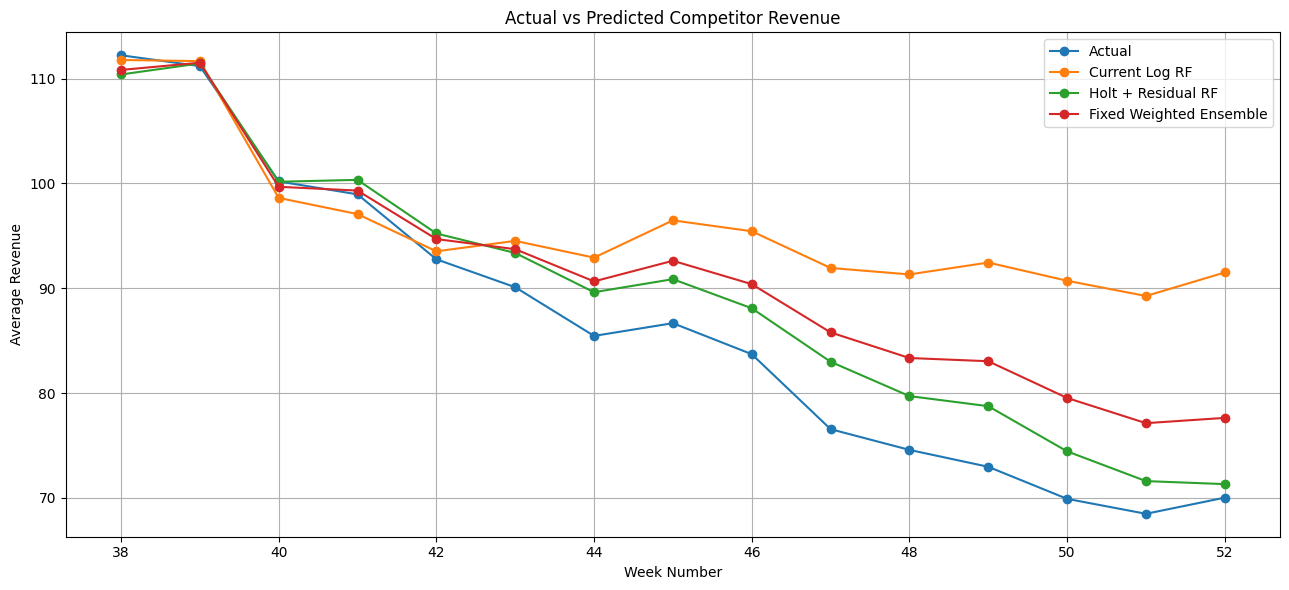


SAVED FILES
- final_test_point_predictions.csv
- final_weekly_point_predictions.csv
- final_point_model_metrics.csv
- final_residual_component_metrics.csv

FINAL SELECTED MODEL
Model : Fixed Weighted Ensemble
Weight Current Log RF      : 0.313
Weight Holt + Residual RF  : 0.687
MAE   : 12.2340
RMSE  : 18.6568
R2    : 0.8760


In [3]:
# ============================================================
# FINAL CLEAN POINT MODEL ONLY
#
# Case Study:
#   Competitor airfare / revenue prediction
#
# Models:
#   1. Current Log Random Forest
#   2. Holt Trend + RF Residual
#   3. Fixed Weighted Ensemble
#
# Final model:
#   31.3% Current Log RF
#   68.7% Holt + Residual RF
#
# No range model.
# No prediction intervals.
# No CV rerun.
# ============================================================


# =========================
# 0. Imports
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from statsmodels.tsa.holtwinters import ExponentialSmoothing


# =========================
# 1. Config
# =========================

DATA_PATH = "skyscanner_airfare_data.csv"

FIXED_WEIGHT_LOG_RF = 0.313
FIXED_WEIGHT_HOLT_RESIDUAL = 0.687

assert abs((FIXED_WEIGHT_LOG_RF + FIXED_WEIGHT_HOLT_RESIDUAL) - 1.0) < 1e-9


# =========================
# 2. Helper functions
# =========================

def safe_expm1(x):
    """
    Safely convert log1p prediction back to revenue scale.
    """
    x = np.asarray(x)
    x = np.clip(x, -50, 20)
    return np.maximum(0, np.expm1(x))


def evaluate_model(name, y_true, y_pred):
    """
    Print and return MAE, RMSE, R2.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 60)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }


def make_one_hot_encoder():
    """
    Compatible with older and newer sklearn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_rf_pipeline(categorical_features, numeric_features, min_samples_leaf=5):
    """
    Build Random Forest pipeline with preprocessing.
    """
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, categorical_features),
            ("num", numeric_transformer, numeric_features),
        ],
        remainder="drop",
    )

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=5,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    return pipeline


def dedupe_columns(cols):
    """
    Remove duplicate column names while preserving order.
    """
    return list(dict.fromkeys(cols))


# =========================
# 3. Load data
# =========================

df = pd.read_csv(DATA_PATH)

print("=" * 80)
print("DATA LOADED")
print("=" * 80)
print("Rows before filtering:", len(df))
print("Columns:", len(df.columns))


# =========================
# 4. Basic cleaning + feature engineering
# =========================

df = df.copy()

df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

df = df.dropna(
    subset=[
        "Revenue",
        "FlightWeek",
        "MainAirlineCarrier",
    ]
).copy()

# Remove Eurowings rows because the target is competitor airfare / revenue
df = df[df["MainAirlineCarrier"] != "EW"].copy()

df["WeekNumber"] = (
    df["FlightWeek"]
    .astype(str)
    .str.extract(r"W(\d+)")
    .astype(int)
)

df["Route"] = (
    df["OriginAirport"].astype(str)
    + "_"
    + df["DestinationAirport"].astype(str)
)

df["CountryRoute"] = (
    df["OriginCountry"].astype(str)
    + "_"
    + df["DestinationCountry"].astype(str)
)

df["WeekSin"] = np.sin(2 * np.pi * df["WeekNumber"] / 52)
df["WeekCos"] = np.cos(2 * np.pi * df["WeekNumber"] / 52)

df["LogRevenue"] = np.log1p(df["Revenue"])

# Make numeric columns safe
numeric_cols_to_clean = [
    "IsConnectingFlight",
    "NumberOfNights",
    "BookingHorizon",
]

for col in numeric_cols_to_clean:
    if col in df.columns:
        if col == "IsConnectingFlight":
            s = df[col]

            if s.dtype == bool:
                df[col] = s.astype(int)
            else:
                map_values = {
                    "true": 1,
                    "false": 0,
                    "yes": 1,
                    "no": 0,
                    "1": 1,
                    "0": 0,
                }

                mapped = s.astype(str).str.lower().map(map_values)
                numeric = pd.to_numeric(s, errors="coerce")

                df[col] = (
                    mapped
                    .fillna(numeric)
                    .fillna(0)
                    .astype(int)
                )
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")


print("\n" + "=" * 80)
print("DATA AFTER FILTERING COMPETITOR ROWS")
print("=" * 80)
print("Rows after removing EW:", len(df))
print("Week range:", df["WeekNumber"].min(), "to", df["WeekNumber"].max())


# =========================
# 5. Feature lists
# =========================

BASE_FEATURES = [
    "WeekNumber",
    "WeekSin",
    "WeekCos",
    "Route",
    "CountryRoute",
    "OriginAirport",
    "OriginCountry",
    "DestinationAirport",
    "DestinationCountry",
    "MainAirlineCarrier",
    "IsConnectingFlight",
    "UserCountry",
    "TripType",
    "CabinClass",
    "NumberOfNights",
    "BookingHorizon",
]

CATEGORICAL_FEATURES = [
    "Route",
    "CountryRoute",
    "OriginAirport",
    "OriginCountry",
    "DestinationAirport",
    "DestinationCountry",
    "MainAirlineCarrier",
    "UserCountry",
    "TripType",
    "CabinClass",
]

NUMERIC_FEATURES = [
    "WeekNumber",
    "WeekSin",
    "WeekCos",
    "IsConnectingFlight",
    "NumberOfNights",
    "BookingHorizon",
]

RESIDUAL_FEATURES = [
    col for col in BASE_FEATURES
    if col not in ["WeekNumber", "WeekSin", "WeekCos"]
]

RESIDUAL_CATEGORICAL_FEATURES = [
    col for col in CATEGORICAL_FEATURES
    if col in RESIDUAL_FEATURES
]

RESIDUAL_NUMERIC_FEATURES = [
    col for col in NUMERIC_FEATURES
    if col in RESIDUAL_FEATURES
]


# =========================
# 6. Leakage safety checks
# =========================

BAD_FEATURES = {
    "Revenue",
    "LogRevenue",
    "ResidualLogRevenue",
    "TrendLogPrediction",
    "RedirectsCount",
    "NumberOfRedirects",
    "Bookings",
    "BookingCount",
}

assert not any(col in BAD_FEATURES for col in BASE_FEATURES), \
    "Leakage risk: bad target/future column found in BASE_FEATURES."

assert not any(col in BAD_FEATURES for col in RESIDUAL_FEATURES), \
    "Leakage risk: bad target/future column found in RESIDUAL_FEATURES."

missing_features = [col for col in BASE_FEATURES if col not in df.columns]

assert len(missing_features) == 0, \
    f"Missing required features: {missing_features}"

print("\nLeakage feature check passed.")
print("All required model features exist.")


# =========================
# 7. Time split
# =========================

train_df = df[df["WeekNumber"].between(1, 37)].copy()
test_df = df[df["WeekNumber"].between(38, 52)].copy()

train_weeks = sorted(train_df["WeekNumber"].unique())
test_weeks = sorted(test_df["WeekNumber"].unique())

assert len(train_df) > 0, "Train data is empty."
assert len(test_df) > 0, "Test data is empty."

assert set(train_weeks).isdisjoint(set(test_weeks)), \
    "Leakage: train and test weeks overlap!"

assert max(train_weeks) < min(test_weeks), \
    "Leakage: train weeks must be before test weeks!"

print("\n" + "=" * 80)
print("TIME SPLIT")
print("=" * 80)
print(f"Train weeks : W{min(train_weeks):02d} to W{max(train_weeks):02d}")
print(f"Test weeks  : W{min(test_weeks):02d} to W{max(test_weeks):02d}")
print(f"Train rows  : {len(train_df)}")
print(f"Test rows   : {len(test_df)}")


# =========================
# 8. Model 1: Current Log RF
# =========================

def fit_predict_current_log_rf(train_part_df, pred_part_df):
    """
    Train standard log Revenue RF.
    """
    model = build_rf_pipeline(
        CATEGORICAL_FEATURES,
        NUMERIC_FEATURES,
        min_samples_leaf=5,
    )

    model.fit(
        train_part_df[BASE_FEATURES],
        train_part_df["LogRevenue"],
    )

    pred_log = model.predict(pred_part_df[BASE_FEATURES])
    pred_revenue = safe_expm1(pred_log)

    return pred_log, pred_revenue, model


# =========================
# 9. Model 2: Holt + RF Residual
# =========================

def fit_holt_trend(train_part_df, train_part_weeks, pred_weeks):
    """
    Fit Holt damped trend only on training weeks.
    Forecast prediction weeks.
    """
    weekly_train_log = (
        train_part_df
        .groupby("WeekNumber")["LogRevenue"]
        .mean()
        .reindex(train_part_weeks)
        .interpolate()
        .ffill()
        .bfill()
    )

    holt_model = ExponentialSmoothing(
        weekly_train_log.values,
        trend="add",
        damped_trend=True,
        seasonal=None,
        initialization_method="estimated",
    ).fit(optimized=True)

    trend_train_log = pd.Series(
        holt_model.fittedvalues,
        index=train_part_weeks,
    )

    trend_pred_log = pd.Series(
        holt_model.forecast(len(pred_weeks)),
        index=pred_weeks,
    )

    return trend_train_log, trend_pred_log, holt_model


def fit_predict_holt_residual_rf_with_parts(
    train_part_df,
    pred_part_df,
    train_part_weeks,
    pred_weeks,
):
    """
    Train Holt trend + RF residual.

    Final log prediction:
        HoltTrendLog + RFResidualLog
    """
    train_part_df = train_part_df.copy()
    pred_part_df = pred_part_df.copy()

    trend_train_log, trend_pred_log, holt_model = fit_holt_trend(
        train_part_df=train_part_df,
        train_part_weeks=train_part_weeks,
        pred_weeks=pred_weeks,
    )

    train_part_df["TrendLogPrediction"] = train_part_df["WeekNumber"].map(
        trend_train_log
    )

    pred_part_df["TrendLogPrediction"] = pred_part_df["WeekNumber"].map(
        trend_pred_log
    )

    train_part_df["ResidualLogRevenue"] = (
        train_part_df["LogRevenue"]
        - train_part_df["TrendLogPrediction"]
    )

    residual_model = build_rf_pipeline(
        RESIDUAL_CATEGORICAL_FEATURES,
        RESIDUAL_NUMERIC_FEATURES,
        min_samples_leaf=5,
    )

    residual_model.fit(
        train_part_df[RESIDUAL_FEATURES],
        train_part_df["ResidualLogRevenue"],
    )

    residual_pred_log = residual_model.predict(
        pred_part_df[RESIDUAL_FEATURES]
    )

    trend_pred_log_by_row = pred_part_df["TrendLogPrediction"].values

    final_log_pred = trend_pred_log_by_row + residual_pred_log
    final_revenue_pred = safe_expm1(final_log_pred)

    return {
        "final_log_pred": final_log_pred,
        "final_revenue_pred": final_revenue_pred,
        "trend_log_pred": trend_pred_log_by_row,
        "residual_log_pred": residual_pred_log,
        "holt_model": holt_model,
        "residual_model": residual_model,
    }


# =========================
# 10. Final fixed weighted ensemble
# =========================

def fit_predict_final_point_model(
    train_part_df,
    pred_part_df,
    train_part_weeks,
    pred_weeks,
):
    """
    Fits both point models and creates final fixed weighted ensemble.
    """
    current_log_pred, current_revenue_pred, current_model = fit_predict_current_log_rf(
        train_part_df=train_part_df,
        pred_part_df=pred_part_df,
    )

    holt_parts = fit_predict_holt_residual_rf_with_parts(
        train_part_df=train_part_df,
        pred_part_df=pred_part_df,
        train_part_weeks=train_part_weeks,
        pred_weeks=pred_weeks,
    )

    holt_log_pred = holt_parts["final_log_pred"]
    holt_revenue_pred = holt_parts["final_revenue_pred"]

    weighted_revenue_pred = (
        FIXED_WEIGHT_LOG_RF * current_revenue_pred
        + FIXED_WEIGHT_HOLT_RESIDUAL * holt_revenue_pred
    )

    weighted_log_pred = np.log1p(weighted_revenue_pred)

    output_base_cols = [
        "FlightWeek",
        "WeekNumber",
        "Revenue",
        "LogRevenue",
    ] + BASE_FEATURES

    output_base_cols = dedupe_columns(output_base_cols)

    out = pred_part_df[output_base_cols].copy()

    # Extra safety against duplicate columns
    out = out.loc[:, ~out.columns.duplicated()].copy()

    out["Pred_CurrentLogRF"] = current_revenue_pred
    out["Pred_HoltResidualRF"] = holt_revenue_pred
    out["Pred_WeightedEnsemble"] = weighted_revenue_pred

    out["LogPred_CurrentLogRF"] = current_log_pred
    out["LogPred_HoltResidualRF"] = holt_log_pred
    out["LogPred_WeightedEnsemble"] = weighted_log_pred

    out["HoltTrendLogPred"] = holt_parts["trend_log_pred"]
    out["HoltResidualLogPred"] = holt_parts["residual_log_pred"]

    out["ActualHoltResidualLog"] = (
        out["LogRevenue"]
        - out["HoltTrendLogPred"]
    )

    out["PointError"] = (
        out["Revenue"]
        - out["Pred_WeightedEnsemble"]
    )

    out["AbsPointError"] = np.abs(out["PointError"])

    return out, current_model, holt_parts


# =========================
# 11. Train final model and evaluate
# =========================

print("\n" + "=" * 80)
print("FINAL POINT MODEL ON FULL TRAIN")
print("=" * 80)

test_point_df, final_log_rf_model, final_holt_parts = fit_predict_final_point_model(
    train_part_df=train_df,
    pred_part_df=test_df,
    train_part_weeks=train_weeks,
    pred_weeks=test_weeks,
)


# =========================
# 12. Final point model metrics
# =========================

point_metrics = []

point_metrics.append(
    evaluate_model(
        "Test: Current Log RF",
        test_point_df["Revenue"],
        test_point_df["Pred_CurrentLogRF"],
    )
)

point_metrics.append(
    evaluate_model(
        "Test: Holt + Residual RF",
        test_point_df["Revenue"],
        test_point_df["Pred_HoltResidualRF"],
    )
)

point_metrics.append(
    evaluate_model(
        "Test: Fixed Weighted Ensemble",
        test_point_df["Revenue"],
        test_point_df["Pred_WeightedEnsemble"],
    )
)

point_metrics_df = pd.DataFrame(point_metrics)

print("\n" + "=" * 80)
print("POINT MODEL FINAL TEST COMPARISON")
print("=" * 80)
print(point_metrics_df.sort_values("MAE").to_string(index=False))


# =========================
# 13. Residual component metrics
# =========================

residual_component_metrics = []

residual_component_metrics.append(
    evaluate_model(
        "Test: RF Residual Component - Log Scale",
        test_point_df["ActualHoltResidualLog"],
        test_point_df["HoltResidualLogPred"],
    )
)

residual_component_metrics_df = pd.DataFrame(residual_component_metrics)


# =========================
# 14. Weekly comparison
# =========================

weekly_comparison = (
    test_point_df
    .groupby(["FlightWeek", "WeekNumber"], as_index=False)
    .agg(
        ActualRevenue=("Revenue", "mean"),
        CurrentLogRF=("Pred_CurrentLogRF", "mean"),
        HoltResidualRF=("Pred_HoltResidualRF", "mean"),
        WeightedEnsemble=("Pred_WeightedEnsemble", "mean"),
        MAE_Weighted=("AbsPointError", "mean"),
    )
    .sort_values("WeekNumber")
)

weekly_comparison["WeightedError"] = (
    weekly_comparison["ActualRevenue"]
    - weekly_comparison["WeightedEnsemble"]
)

print("\n" + "=" * 80)
print("WEEKLY TEST COMPARISON")
print("=" * 80)
print(weekly_comparison.to_string(index=False))


# =========================
# 15. Plot weekly actual vs predicted
# =========================

plt.figure(figsize=(13, 6))

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["ActualRevenue"],
    marker="o",
    label="Actual",
)

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["CurrentLogRF"],
    marker="o",
    label="Current Log RF",
)

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["HoltResidualRF"],
    marker="o",
    label="Holt + Residual RF",
)

plt.plot(
    weekly_comparison["WeekNumber"],
    weekly_comparison["WeightedEnsemble"],
    marker="o",
    label="Fixed Weighted Ensemble",
)

plt.xlabel("Week Number")
plt.ylabel("Average Revenue")
plt.title("Actual vs Predicted Competitor Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================
# 16. Save clean outputs
# =========================

test_output_cols = [
    "FlightWeek",
    "WeekNumber",
    "Revenue",
    "Pred_CurrentLogRF",
    "Pred_HoltResidualRF",
    "Pred_WeightedEnsemble",
    "PointError",
    "AbsPointError",
]

test_point_df[test_output_cols].to_csv(
    "final_test_point_predictions.csv",
    index=False,
)

weekly_comparison.to_csv(
    "final_weekly_point_predictions.csv",
    index=False,
)

point_metrics_df.to_csv(
    "final_point_model_metrics.csv",
    index=False,
)

residual_component_metrics_df.to_csv(
    "final_residual_component_metrics.csv",
    index=False,
)

print("\n" + "=" * 80)
print("SAVED FILES")
print("=" * 80)
print("- final_test_point_predictions.csv")
print("- final_weekly_point_predictions.csv")
print("- final_point_model_metrics.csv")
print("- final_residual_component_metrics.csv")


# =========================
# 17. Final summary print
# =========================

best_row = point_metrics_df.sort_values("MAE").iloc[0]

print("\n" + "=" * 80)
print("FINAL SELECTED MODEL")
print("=" * 80)
print("Model : Fixed Weighted Ensemble")
print(f"Weight Current Log RF      : {FIXED_WEIGHT_LOG_RF:.3f}")
print(f"Weight Holt + Residual RF  : {FIXED_WEIGHT_HOLT_RESIDUAL:.3f}")
print(f"MAE   : {best_row['MAE']:.4f}")
print(f"RMSE  : {best_row['RMSE']:.4f}")
print(f"R2    : {best_row['R2']:.4f}")

MODEL 1: CURRENT LOG RF - TOP TRANSFORMED FEATURES
                        Feature  Importance
        cat__CabinClass_Economy    0.318994
                   num__WeekCos    0.163204
     cat__MainAirlineCarrier_LH    0.116206
                num__WeekNumber    0.098212
       cat__CabinClass_Business    0.056445
            num__BookingHorizon    0.037573
cat__CabinClass_Premium Economy    0.023622
     cat__DestinationCountry_TR    0.019940
     cat__MainAirlineCarrier_DE    0.018214
        num__IsConnectingFlight    0.014643
     cat__MainAirlineCarrier_X3    0.013500
                   num__WeekSin    0.011241
            num__NumberOfNights    0.010852
    cat__DestinationAirport_ACE    0.009130
    cat__DestinationAirport_TFS    0.008487
    cat__DestinationAirport_LPA    0.007986
    cat__DestinationAirport_FUE    0.007556
     cat__MainAirlineCarrier_VY    0.005582
     cat__MainAirlineCarrier_TO    0.005493
    cat__DestinationAirport_SKP    0.004631
     cat__DestinationCoun

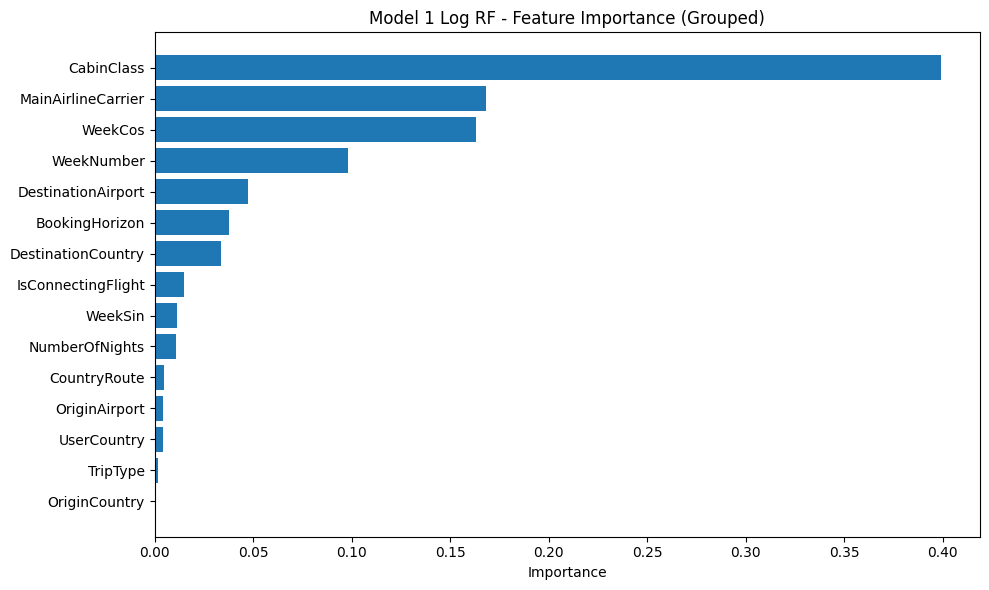


MODEL 2: RESIDUAL RF - TOP TRANSFORMED FEATURES
                        Feature  Importance
        cat__CabinClass_Economy    0.428223
     cat__MainAirlineCarrier_LH    0.154146
cat__CabinClass_Premium Economy    0.055381
       cat__CabinClass_Business    0.055242
            num__BookingHorizon    0.047587
     cat__DestinationCountry_TR    0.028087
     cat__MainAirlineCarrier_DE    0.024636
        num__IsConnectingFlight    0.022559
     cat__MainAirlineCarrier_X3    0.018954
    cat__DestinationAirport_ACE    0.014630
            num__NumberOfNights    0.014584
    cat__DestinationAirport_LPA    0.014287
    cat__DestinationAirport_TFS    0.013934
    cat__DestinationAirport_FUE    0.013763
     cat__MainAirlineCarrier_VY    0.009188
     cat__MainAirlineCarrier_TO    0.009042
     cat__DestinationCountry_AL    0.007604
     cat__DestinationCountry_MK    0.007545
    cat__DestinationAirport_SKP    0.007241
    cat__DestinationAirport_TIA    0.006645
     cat__MainAirlineCarrie

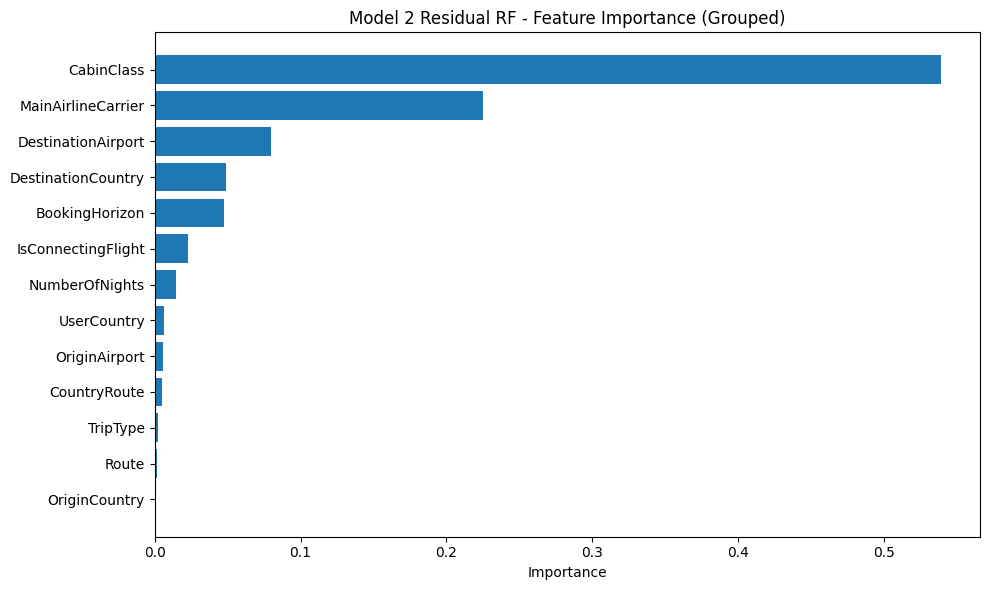


SAVED FEATURE IMPORTANCE FILES
- model1_log_rf_feature_importance.csv
- model1_log_rf_feature_importance_grouped.csv
- model2_residual_rf_feature_importance.csv
- model2_residual_rf_feature_importance_grouped.csv


In [4]:
# ============================================================
# FEATURE IMPORTANCE
# For:
#   1. final_log_rf_model          (Current Log RF)
#   2. final_holt_parts["residual_model"]  (Holt + Residual RF)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


def get_rf_feature_importance(pipeline, top_n=30):
    """
    Extract RF feature importances from a fitted sklearn Pipeline
    with ColumnTransformer + OneHotEncoder preprocessing.
    """
    preprocessor = pipeline.named_steps["preprocessor"]
    rf_model = pipeline.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    importances = rf_model.feature_importances_

    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances,
        })
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    print(importance_df.head(top_n).to_string(index=False))
    return importance_df


def aggregate_importance_by_raw_feature(importance_df):
    """
    Group one-hot columns back to original feature names.
    Example: cat__Route_CGN_LHR -> Route
    """
    def to_raw_name(name):
        # handle nested pipeline names from ColumnTransformer
        if name.startswith("cat__"):
            # cat__onehot__Route_CGN_LHR  OR  cat__Route_CGN_LHR
            parts = name.split("__")
            if len(parts) >= 3:
                return parts[2].split("_", 1)[0]
            if len(parts) == 2:
                return parts[1].split("_", 1)[0]

        if name.startswith("num__"):
            return name.replace("num__", "")

        return name

    grouped = (
        importance_df
        .assign(RawFeature=importance_df["Feature"].map(to_raw_name))
        .groupby("RawFeature", as_index=False)["Importance"]
        .sum()
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    return grouped


def plot_top_features(importance_df, feature_col, title, top_n=15):
    top = importance_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(top[feature_col], top["Importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


# ============================================================
# 1) MODEL 1: CURRENT LOG RF
# ============================================================

print("=" * 80)
print("MODEL 1: CURRENT LOG RF - TOP TRANSFORMED FEATURES")
print("=" * 80)

log_rf_importance = get_rf_feature_importance(final_log_rf_model, top_n=30)

log_rf_grouped = aggregate_importance_by_raw_feature(log_rf_importance)

print("\nMODEL 1: GROUPED BY ORIGINAL FEATURE")
print("-" * 80)
print(log_rf_grouped.head(20).to_string(index=False))

plot_top_features(
    log_rf_grouped,
    feature_col="RawFeature",
    title="Model 1 Log RF - Feature Importance (Grouped)",
    top_n=15,
)


# ============================================================
# 2) MODEL 2: RESIDUAL RF (inside Holt + Residual)
# ============================================================

print("\n" + "=" * 80)
print("MODEL 2: RESIDUAL RF - TOP TRANSFORMED FEATURES")
print("=" * 80)

residual_model = final_holt_parts["residual_model"]

residual_importance = get_rf_feature_importance(residual_model, top_n=30)

residual_grouped = aggregate_importance_by_raw_feature(residual_importance)

print("\nMODEL 2: GROUPED BY ORIGINAL FEATURE")
print("-" * 80)
print(residual_grouped.head(20).to_string(index=False))

plot_top_features(
    residual_grouped,
    feature_col="RawFeature",
    title="Model 2 Residual RF - Feature Importance (Grouped)",
    top_n=15,
)


# ============================================================
# 3) SAVE OUTPUTS
# ============================================================

log_rf_importance.to_csv("model1_log_rf_feature_importance.csv", index=False)
log_rf_grouped.to_csv("model1_log_rf_feature_importance_grouped.csv", index=False)

residual_importance.to_csv("model2_residual_rf_feature_importance.csv", index=False)
residual_grouped.to_csv("model2_residual_rf_feature_importance_grouped.csv", index=False)

print("\n" + "=" * 80)
print("SAVED FEATURE IMPORTANCE FILES")
print("=" * 80)
print("- model1_log_rf_feature_importance.csv")
print("- model1_log_rf_feature_importance_grouped.csv")
print("- model2_residual_rf_feature_importance.csv")
print("- model2_residual_rf_feature_importance_grouped.csv")

EW rows total : 13,584
EW W01-W37    : 9,689
EW W38-W52    : 3,895

EW W01-W37: Weighted Ensemble (transfer)
------------------------------------------------------------
MAE  : 40.1914
RMSE : 54.1435
R2   : 0.4457

EW W38-W52: Weighted Ensemble (transfer)
------------------------------------------------------------
MAE  : 21.5476
RMSE : 29.3419
R2   : 0.6689

Competitor W38-W52: Weighted Ensemble (official test)
------------------------------------------------------------
MAE  : 10.6057
RMSE : 16.1395
R2   : 0.8781

                                                 Model       MAE      RMSE       R2
             EW W01-W37: Weighted Ensemble (transfer) 40.191429 54.143541 0.445699
             EW W38-W52: Weighted Ensemble (transfer) 21.547610 29.341896 0.668907
Competitor W38-W52: Weighted Ensemble (official test) 10.605744 16.139453 0.878084


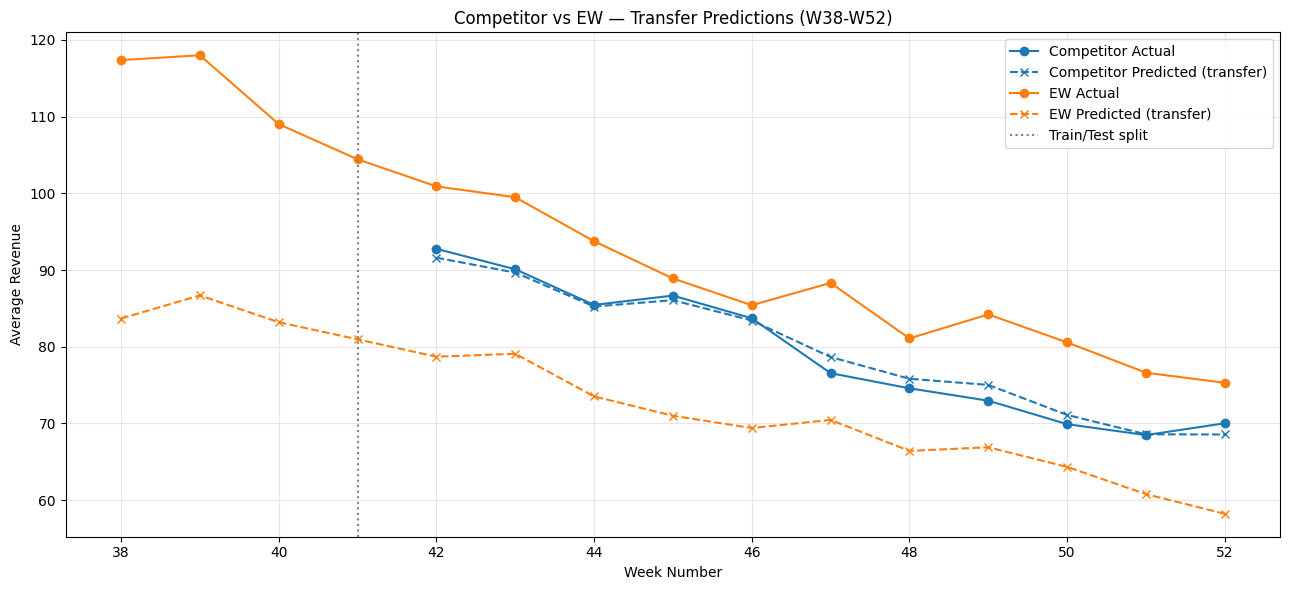

In [3]:
# ============================================================
# EW TRANSFER TEST — predict only (NO training on EW)
# Uses competitor-trained models from section 11
# ============================================================

def engineer_features_for_scoring(part_df):
    """Same feature engineering as pred3 section 4."""
    part_df = part_df.copy()

    part_df["Route"] = (
        part_df["OriginAirport"].astype(str)
        + "_"
        + part_df["DestinationAirport"].astype(str)
    )
    part_df["CountryRoute"] = (
        part_df["OriginCountry"].astype(str)
        + "_"
        + part_df["DestinationCountry"].astype(str)
    )
    part_df["WeekSin"] = np.sin(2 * np.pi * part_df["WeekNumber"] / 52)
    part_df["WeekCos"] = np.cos(2 * np.pi * part_df["WeekNumber"] / 52)
    part_df["LogRevenue"] = np.log1p(part_df["Revenue"])

    if "IsConnectingFlight" in part_df.columns:
        s = part_df["IsConnectingFlight"]
        if s.dtype == bool:
            part_df["IsConnectingFlight"] = s.astype(int)
        else:
            map_values = {
                "true": 1, "false": 0, "yes": 1, "no": 0, "1": 1, "0": 0,
            }
            mapped = s.astype(str).str.lower().map(map_values)
            numeric = pd.to_numeric(s, errors="coerce")
            part_df["IsConnectingFlight"] = (
                mapped.fillna(numeric).fillna(0).astype(int)
            )

    for col in ["NumberOfNights", "BookingHorizon"]:
        if col in part_df.columns:
            part_df[col] = pd.to_numeric(part_df[col], errors="coerce")

    return part_df


def predict_frozen_ensemble(pred_df, log_rf_model, holt_parts):
    """
    Predict only — no .fit() on pred_df.
    holt_parts = final_holt_parts from competitor training.
    """
    pred_df = pred_df.copy()
    holt_model = holt_parts["holt_model"]
    residual_model = holt_parts["residual_model"]

    max_train_week = max(train_weeks)

    trend_log_by_week = {}
    for week in sorted(pred_df["WeekNumber"].unique()):
        steps_ahead = week - max_train_week
        if steps_ahead <= 0:
            # should not happen for EW test W38+, but safe fallback
            trend_log_by_week[week] = holt_model.fittedvalues[-1]
        else:
            trend_log_by_week[week] = holt_model.forecast(steps_ahead)[-1]

    pred_df["TrendLogPrediction"] = pred_df["WeekNumber"].map(trend_log_by_week)

    current_log_pred = log_rf_model.predict(pred_df[BASE_FEATURES])
    current_revenue_pred = safe_expm1(current_log_pred)

    residual_log_pred = residual_model.predict(pred_df[RESIDUAL_FEATURES])
    holt_log_pred = pred_df["TrendLogPrediction"].values + residual_log_pred
    holt_revenue_pred = safe_expm1(holt_log_pred)

    weighted_revenue_pred = (
        FIXED_WEIGHT_LOG_RF * current_revenue_pred
        + FIXED_WEIGHT_HOLT_RESIDUAL * holt_revenue_pred
    )

    out = pred_df.copy()
    out["Pred_CurrentLogRF"] = current_revenue_pred
    out["Pred_HoltResidualRF"] = holt_revenue_pred
    out["Pred_WeightedEnsemble"] = weighted_revenue_pred
    out["AbsPointError"] = np.abs(out["Revenue"] - out["Pred_WeightedEnsemble"])

    return out


# --- Load EW only ---
raw = pd.read_csv(DATA_PATH)
raw["Revenue"] = pd.to_numeric(raw["Revenue"], errors="coerce")
raw["MainAirlineCarrier"] = raw["MainAirlineCarrier"].astype(str).str.upper()
raw["WeekNumber"] = (
    raw["FlightWeek"].astype(str).str.extract(r"W(\d+)").astype(int)
)

ew_df = (
    raw[raw["MainAirlineCarrier"] == "EW"]
    .dropna(subset=["Revenue", "WeekNumber", "FlightWeek"])
    .copy()
)

ew_df = engineer_features_for_scoring(ew_df)

ew_early = ew_df[ew_df["WeekNumber"].between(1, 37)].copy()
ew_late  = ew_df[ew_df["WeekNumber"].between(38, 52)].copy()

print(f"EW rows total : {len(ew_df):,}")
print(f"EW W01-W37    : {len(ew_early):,}")
print(f"EW W38-W52    : {len(ew_late):,}")

# --- Predict only (frozen competitor models) ---
ew_early_out = predict_frozen_ensemble(
    ew_early, final_log_rf_model, final_holt_parts
)
ew_late_out = predict_frozen_ensemble(
    ew_late, final_log_rf_model, final_holt_parts
)

# --- Metrics ---
transfer_metrics = []

transfer_metrics.append(
    evaluate_model(
        "EW W01-W37: Weighted Ensemble (transfer)",
        ew_early_out["Revenue"],
        ew_early_out["Pred_WeightedEnsemble"],
    )
)
transfer_metrics.append(
    evaluate_model(
        "EW W38-W52: Weighted Ensemble (transfer)",
        ew_late_out["Revenue"],
        ew_late_out["Pred_WeightedEnsemble"],
    )
)
transfer_metrics.append(
    evaluate_model(
        "Competitor W38-W52: Weighted Ensemble (official test)",
        test_point_df["Revenue"],
        test_point_df["Pred_WeightedEnsemble"],
    )
)

transfer_metrics_df = pd.DataFrame(transfer_metrics)
print("\n", transfer_metrics_df.to_string(index=False))

# --- Combined weekly picture ---
comp_weekly = (
    test_point_df.groupby("WeekNumber", as_index=False)
    .agg(Actual=("Revenue", "mean"), Predicted=("Pred_WeightedEnsemble", "mean"))
    .assign(Segment="Competitor")
)

ew_weekly = (
    ew_late_out.groupby("WeekNumber", as_index=False)
    .agg(Actual=("Revenue", "mean"), Predicted=("Pred_WeightedEnsemble", "mean"))
    .assign(Segment="EW")
)

plt.figure(figsize=(13, 6))

for segment, data, color in [
    ("Competitor", comp_weekly, "C0"),
    ("EW", ew_weekly, "C1"),
]:
    plt.plot(data["WeekNumber"], data["Actual"], marker="o", color=color,
             label=f"{segment} Actual")
    plt.plot(data["WeekNumber"], data["Predicted"], marker="x", linestyle="--", color=color,
             label=f"{segment} Predicted (transfer)")

plt.axvline(max(train_weeks), color="gray", linestyle=":", label="Train/Test split")
plt.xlabel("Week Number")
plt.ylabel("Average Revenue")
plt.title("Competitor vs EW — Transfer Predictions (W38-W52)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ew_late_out.to_csv("ew_transfer_test_predictions.csv", index=False)
transfer_metrics_df.to_csv("ew_transfer_metrics.csv", index=False)

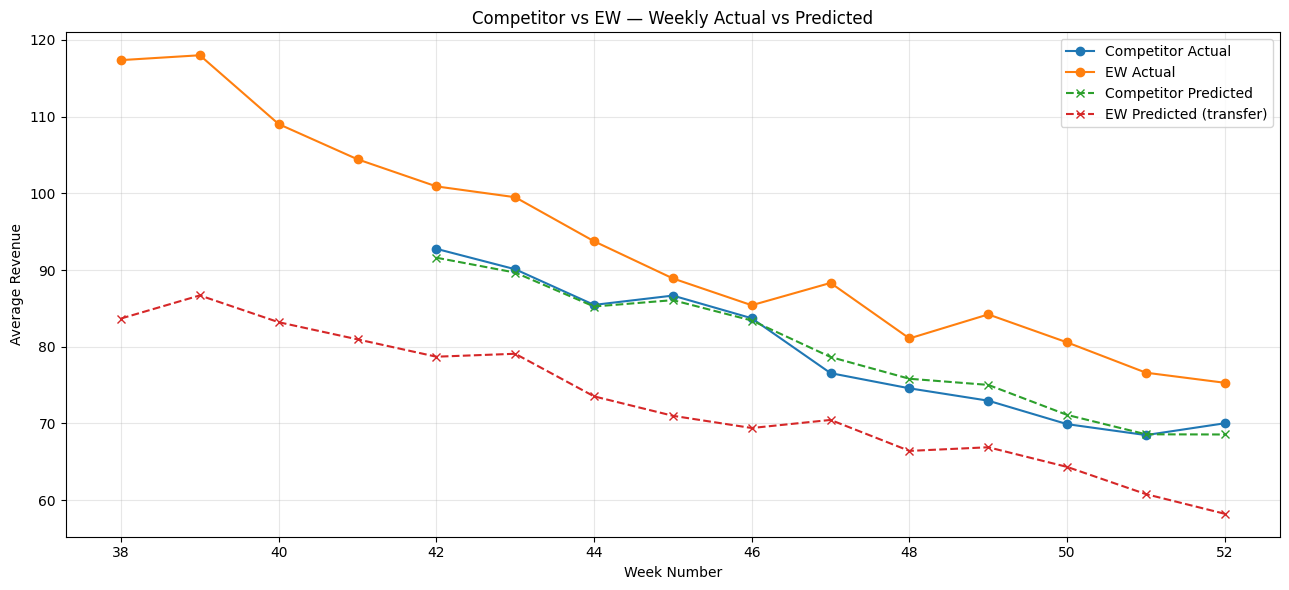

In [5]:
comp_weekly = (
    test_point_df.groupby("WeekNumber")
    .agg(Actual=("Revenue", "mean"), Pred=("Pred_WeightedEnsemble", "mean"))
    .assign(Group="Competitor")
)

ew_weekly = (
    ew_late_out.groupby("WeekNumber")
    .agg(Actual=("Revenue", "mean"), Pred=("Pred_WeightedEnsemble", "mean"))
    .assign(Group="EW")
)

plt.figure(figsize=(13, 6))

plt.plot(comp_weekly.index, comp_weekly["Actual"], "o-", label="Competitor Actual")
plt.plot(ew_weekly.index, ew_weekly["Actual"], "o-", label="EW Actual")
plt.plot(comp_weekly.index, comp_weekly["Pred"], "x--", label="Competitor Predicted")
plt.plot(ew_weekly.index, ew_weekly["Pred"], "x--", label="EW Predicted (transfer)")

plt.xlabel("Week Number")
plt.ylabel("Average Revenue")
plt.title("Competitor vs EW — Weekly Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

FULL METRICS — COMPETITOR vs EW
                     Model       MAE      RMSE       R2  Rows                                      Note
        Competitor W01-W37 20.831971 30.955036 0.809318 32638   In-sample (model trained on these rows)
        Competitor W38-W52 10.605744 16.139453 0.878084  8778               Official out-of-sample test
   Competitor W01-W52 FULL 18.664552 28.466329 0.824746 41416         Mixed: train in-sample + test OOS
     EW W01-W37 (transfer) 40.191429 54.143541 0.445699  9689 EW never in training; carrier OHE unknown
     EW W38-W52 (transfer) 21.547610 29.341896 0.668907  3895      Same future weeks as competitor test
EW W01-W52 FULL (transfer) 34.845605 48.350984 0.505749 13584                    Full EW transfer check


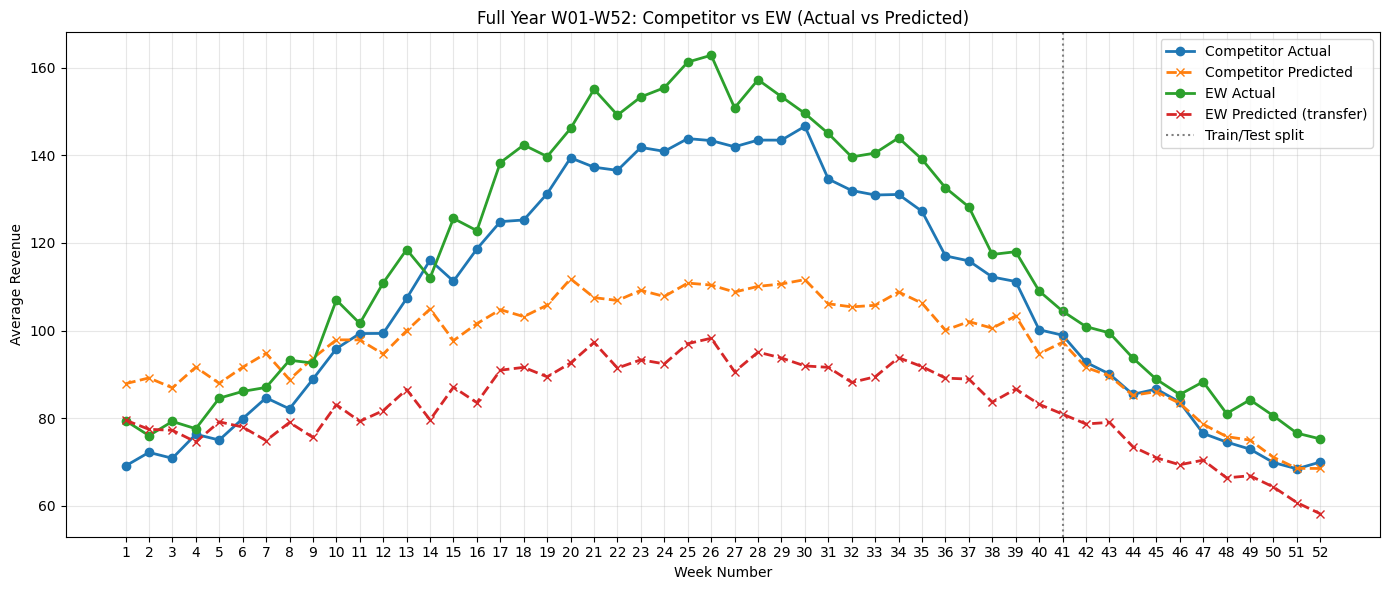

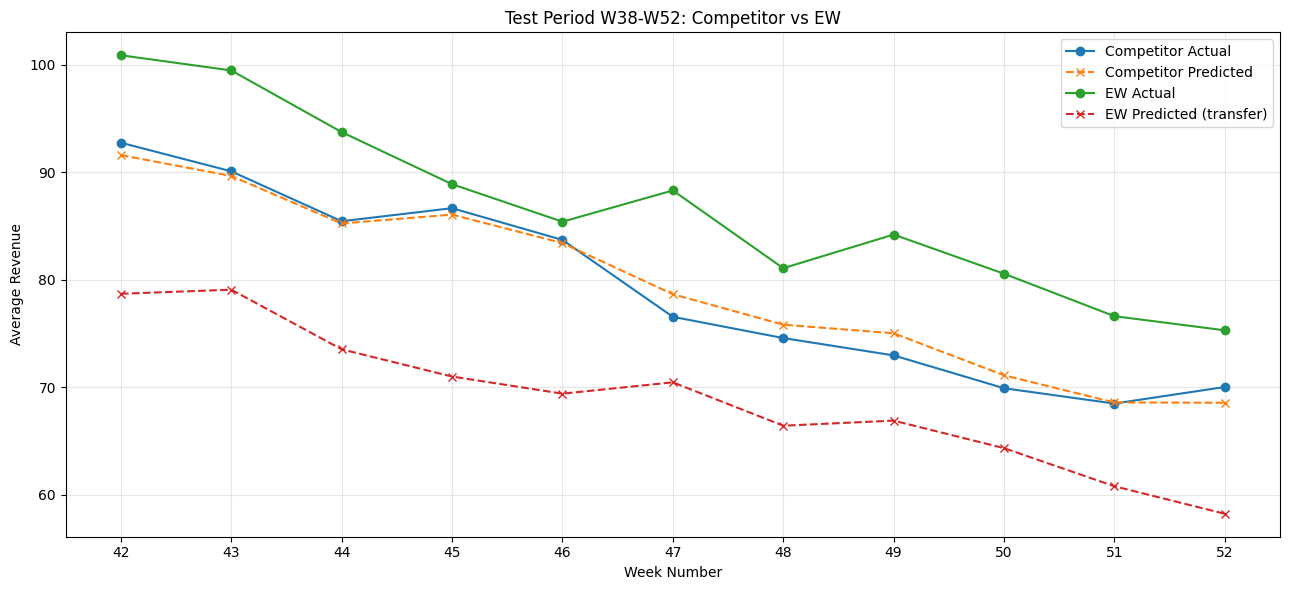

In [6]:
# ============================================================
# FULL PICTURE: Competitor + EW (all weeks)
# ============================================================

def add_metrics_row(rows, name, y_true, y_pred, note=""):
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Rows": len(y_true),
        "Note": note,
    })


# --- Competitor: predict on train + test (frozen models) ---
comp_train_out = predict_frozen_ensemble(
    train_df, final_log_rf_model, final_holt_parts
)
comp_test_out = test_point_df.copy()   # already have this from section 11

comp_full_out = pd.concat(
    [comp_train_out, comp_test_out],
    ignore_index=True,
)

# --- EW: full W01-W52 ---
ew_full_out = pd.concat(
    [ew_early_out, ew_late_out],
    ignore_index=True,
)


# --- Metrics table ---
full_metrics = []

add_metrics_row(
    full_metrics,
    "Competitor W01-W37",
    comp_train_out["Revenue"],
    comp_train_out["Pred_WeightedEnsemble"],
    note="In-sample (model trained on these rows)",
)

add_metrics_row(
    full_metrics,
    "Competitor W38-W52",
    comp_test_out["Revenue"],
    comp_test_out["Pred_WeightedEnsemble"],
    note="Official out-of-sample test",
)

add_metrics_row(
    full_metrics,
    "Competitor W01-W52 FULL",
    comp_full_out["Revenue"],
    comp_full_out["Pred_WeightedEnsemble"],
    note="Mixed: train in-sample + test OOS",
)

add_metrics_row(
    full_metrics,
    "EW W01-W37 (transfer)",
    ew_early_out["Revenue"],
    ew_early_out["Pred_WeightedEnsemble"],
    note="EW never in training; carrier OHE unknown",
)

add_metrics_row(
    full_metrics,
    "EW W38-W52 (transfer)",
    ew_late_out["Revenue"],
    ew_late_out["Pred_WeightedEnsemble"],
    note="Same future weeks as competitor test",
)

add_metrics_row(
    full_metrics,
    "EW W01-W52 FULL (transfer)",
    ew_full_out["Revenue"],
    ew_full_out["Pred_WeightedEnsemble"],
    note="Full EW transfer check",
)

full_metrics_df = pd.DataFrame(full_metrics)

print("=" * 100)
print("FULL METRICS — COMPETITOR vs EW")
print("=" * 100)
print(full_metrics_df.to_string(index=False))

full_metrics_df.to_csv("competitor_vs_ew_full_metrics.csv", index=False)


# --- Weekly averages: FULL year ---
comp_weekly_full = (
    comp_full_out.groupby("WeekNumber", as_index=False)
    .agg(
        Actual=("Revenue", "mean"),
        Predicted=("Pred_WeightedEnsemble", "mean"),
    )
    .assign(Segment="Competitor")
)

ew_weekly_full = (
    ew_full_out.groupby("WeekNumber", as_index=False)
    .agg(
        Actual=("Revenue", "mean"),
        Predicted=("Pred_WeightedEnsemble", "mean"),
    )
    .assign(Segment="EW")
)

combined_weekly_full = pd.concat(
    [comp_weekly_full, ew_weekly_full],
    ignore_index=True,
)
combined_weekly_full.to_csv("competitor_vs_ew_weekly_full.csv", index=False)


# --- Plot 1: Full year, both segments ---
plt.figure(figsize=(14, 6))

plt.plot(
    comp_weekly_full["WeekNumber"],
    comp_weekly_full["Actual"],
    "o-",
    linewidth=2,
    label="Competitor Actual",
)
plt.plot(
    comp_weekly_full["WeekNumber"],
    comp_weekly_full["Predicted"],
    "x--",
    linewidth=2,
    label="Competitor Predicted",
)

plt.plot(
    ew_weekly_full["WeekNumber"],
    ew_weekly_full["Actual"],
    "o-",
    linewidth=2,
    label="EW Actual",
)
plt.plot(
    ew_weekly_full["WeekNumber"],
    ew_weekly_full["Predicted"],
    "x--",
    linewidth=2,
    label="EW Predicted (transfer)",
)

plt.axvline(max(train_weeks), color="gray", linestyle=":", label="Train/Test split")
plt.xlabel("Week Number")
plt.ylabel("Average Revenue")
plt.title("Full Year W01-W52: Competitor vs EW (Actual vs Predicted)")
plt.xticks(range(1, 53))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --- Plot 2: Test period only W38-W52 (apples-to-apples) ---
comp_weekly_test = comp_weekly_full[comp_weekly_full["WeekNumber"] >= min(test_weeks)]
ew_weekly_test = ew_weekly_full[ew_weekly_full["WeekNumber"] >= min(test_weeks)]

plt.figure(figsize=(13, 6))

plt.plot(comp_weekly_test["WeekNumber"], comp_weekly_test["Actual"], "o-", label="Competitor Actual")
plt.plot(comp_weekly_test["WeekNumber"], comp_weekly_test["Predicted"], "x--", label="Competitor Predicted")
plt.plot(ew_weekly_test["WeekNumber"], ew_weekly_test["Actual"], "o-", label="EW Actual")
plt.plot(ew_weekly_test["WeekNumber"], ew_weekly_test["Predicted"], "x--", label="EW Predicted (transfer)")

plt.xlabel("Week Number")
plt.ylabel("Average Revenue")
plt.title("Test Period W38-W52: Competitor vs EW")
plt.xticks(sorted(test_weeks))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


BONUS: EW REDIRECT MODEL 1 - SIMPLE LOG RF
Rows before EW redirect filtering: 55000
Columns: 14
Redirect target column: NumberOfRedirects

EW REDIRECT DATA AFTER FILTERING
Rows after keeping EW only: 13584
Week range: 1 to 52
Total EW redirects: 41888
Average EW redirects per row: 3.0836277974087163

EW redirect leakage feature check passed.
All required EW redirect model features exist.

EW REDIRECT TIME SPLIT
Train weeks : W01 to W37
Test weeks  : W38 to W52
Train rows  : 9689
Test rows   : 3895
Train redirects total: 29198
Test redirects total : 12690

TRAINING EW REDIRECT MODEL 1

Test: EW Redirect Model 1 - Log RF Row Level
------------------------------------------------------------
MAE  : 1.4967
RMSE : 1.9452
R2   : 0.1972

EW REDIRECT MODEL 1 ROW-LEVEL METRICS
                                       Model     MAE     RMSE       R2
Test: EW Redirect Model 1 - Log RF Row Level 1.49674 1.945214 0.197169

Test: EW Redirect Model 1 - Weekly Aggregate
--------------------------------

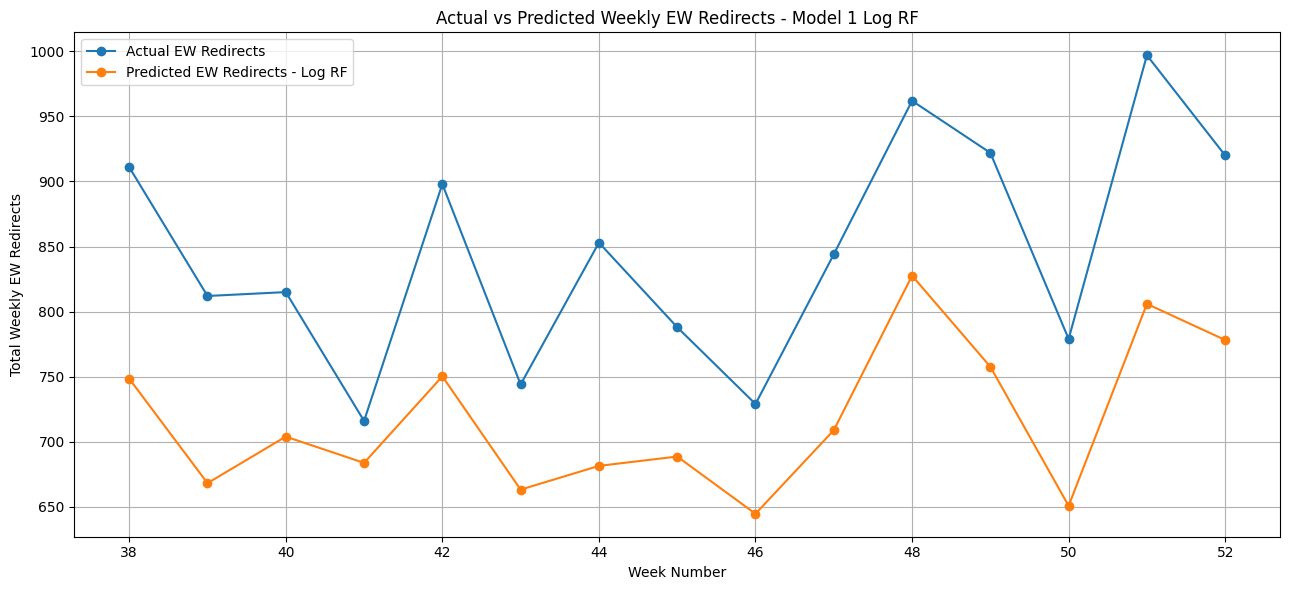


SAVED EW REDIRECT MODEL 1 FILES
- final_ew_redirect_test_predictions_model1.csv
- final_ew_redirect_weekly_predictions_model1.csv
- final_ew_redirect_row_metrics_model1.csv
- final_ew_redirect_weekly_metrics_model1.csv

FINAL EW REDIRECT MODEL 1 SUMMARY
Model  : EW Redirect Model 1 - Current Log RF
Target : Expected EW redirects
Target column used: NumberOfRedirects
Row MAE   : 1.4967
Row RMSE  : 1.9452
Row R2    : 0.1972
Weekly MAE  : 128.5763
Weekly RMSE : 134.5836
Weekly R2   : -1.5764


In [8]:
# ============================================================
# 18. BONUS MODEL 1: EW REDIRECT PREDICTION - SIMPLE LOG RF
#
# Target:
#   Expected number of Eurowings redirects
#
# Model:
#   Model 1 = Current Log Random Forest
#
# Important:
#   This is separate from competitor price model.
#   We reload the full dataset because earlier df removed EW rows.
#   No Holt model.
#   No residual model.
#   No competitor-pressure features yet.
# ============================================================


print("\n" + "=" * 80)
print("BONUS: EW REDIRECT MODEL 1 - SIMPLE LOG RF")
print("=" * 80)


# =========================
# 18.1 Reload full data
# =========================

redirect_df = pd.read_csv("skyscanner_airfare_data.csv")

print("Rows before EW redirect filtering:", len(redirect_df))
print("Columns:", len(redirect_df.columns))


# =========================
# 18.2 Target column detection
# =========================

REDIRECT_TARGET_CANDIDATES = [
    "NumberOfRedirects",
    "RedirectsCount",
]

REDIRECT_TARGET = None

for col in REDIRECT_TARGET_CANDIDATES:
    if col in redirect_df.columns:
        REDIRECT_TARGET = col
        break

assert REDIRECT_TARGET is not None, (
    f"No redirect target column found. Expected one of: {REDIRECT_TARGET_CANDIDATES}"
)

print("Redirect target column:", REDIRECT_TARGET)


# =========================
# 18.3 Basic cleaning + feature engineering
# =========================

redirect_df = redirect_df.copy()

redirect_df[REDIRECT_TARGET] = pd.to_numeric(
    redirect_df[REDIRECT_TARGET],
    errors="coerce",
)

redirect_df = redirect_df.dropna(
    subset=[
        REDIRECT_TARGET,
        "FlightWeek",
        "MainAirlineCarrier",
    ]
).copy()

# Keep only EW rows because target is expected EW redirects
redirect_df = redirect_df[
    redirect_df["MainAirlineCarrier"].astype(str).str.upper() == "EW"
].copy()

redirect_df["WeekNumber"] = (
    redirect_df["FlightWeek"]
    .astype(str)
    .str.extract(r"W(\d+)")
    .astype(int)
)

redirect_df["Route"] = (
    redirect_df["OriginAirport"].astype(str)
    + "_"
    + redirect_df["DestinationAirport"].astype(str)
)

redirect_df["CountryRoute"] = (
    redirect_df["OriginCountry"].astype(str)
    + "_"
    + redirect_df["DestinationCountry"].astype(str)
)

redirect_df["WeekSin"] = np.sin(2 * np.pi * redirect_df["WeekNumber"] / 52)
redirect_df["WeekCos"] = np.cos(2 * np.pi * redirect_df["WeekNumber"] / 52)

# Redirects are count values, so make sure negative values do not exist
redirect_df[REDIRECT_TARGET] = np.maximum(
    0,
    redirect_df[REDIRECT_TARGET],
)

redirect_df["LogRedirects"] = np.log1p(redirect_df[REDIRECT_TARGET])


# =========================
# 18.4 Clean numeric columns
# =========================

numeric_cols_to_clean_redirect = [
    "IsConnectingFlight",
    "NumberOfNights",
    "BookingHorizon",
]

for col in numeric_cols_to_clean_redirect:
    if col in redirect_df.columns:
        if col == "IsConnectingFlight":
            s = redirect_df[col]

            if s.dtype == bool:
                redirect_df[col] = s.astype(int)
            else:
                map_values = {
                    "true": 1,
                    "false": 0,
                    "yes": 1,
                    "no": 0,
                    "1": 1,
                    "0": 0,
                }

                mapped = s.astype(str).str.lower().map(map_values)
                numeric = pd.to_numeric(s, errors="coerce")

                redirect_df[col] = (
                    mapped
                    .fillna(numeric)
                    .fillna(0)
                    .astype(int)
                )
        else:
            redirect_df[col] = pd.to_numeric(
                redirect_df[col],
                errors="coerce",
            )


print("\n" + "=" * 80)
print("EW REDIRECT DATA AFTER FILTERING")
print("=" * 80)
print("Rows after keeping EW only:", len(redirect_df))
print("Week range:", redirect_df["WeekNumber"].min(), "to", redirect_df["WeekNumber"].max())
print("Total EW redirects:", redirect_df[REDIRECT_TARGET].sum())
print("Average EW redirects per row:", redirect_df[REDIRECT_TARGET].mean())


# =========================
# 18.5 Leakage safety checks
# =========================

BAD_REDIRECT_FEATURES = {
    "Revenue",
    "LogRevenue",
    "RedirectsCount",
    "NumberOfRedirects",
    "LogRedirects",
    "Bookings",
    "BookingCount",
}

assert not any(col in BAD_REDIRECT_FEATURES for col in BASE_FEATURES), \
    "Leakage risk: redirect target or outcome column found in BASE_FEATURES."

missing_redirect_features = [
    col for col in BASE_FEATURES
    if col not in redirect_df.columns
]

assert len(missing_redirect_features) == 0, \
    f"Missing redirect model features: {missing_redirect_features}"

print("\nEW redirect leakage feature check passed.")
print("All required EW redirect model features exist.")


# =========================
# 18.6 Time split
# =========================

# Match your current price-model split.
# If your final price model uses W01-W41 / W42-W52, change this to 41.
REDIRECT_TRAIN_END_WEEK = 37

redirect_train_df = redirect_df[
    redirect_df["WeekNumber"].between(1, REDIRECT_TRAIN_END_WEEK)
].copy()

redirect_test_df = redirect_df[
    redirect_df["WeekNumber"].between(REDIRECT_TRAIN_END_WEEK + 1, 52)
].copy()

redirect_train_weeks = sorted(redirect_train_df["WeekNumber"].unique())
redirect_test_weeks = sorted(redirect_test_df["WeekNumber"].unique())

assert len(redirect_train_df) > 0, "EW redirect train data is empty."
assert len(redirect_test_df) > 0, "EW redirect test data is empty."

assert set(redirect_train_weeks).isdisjoint(set(redirect_test_weeks)), \
    "Leakage: redirect train and test weeks overlap!"

assert max(redirect_train_weeks) < min(redirect_test_weeks), \
    "Leakage: redirect train weeks must be before test weeks!"

print("\n" + "=" * 80)
print("EW REDIRECT TIME SPLIT")
print("=" * 80)
print(f"Train weeks : W{min(redirect_train_weeks):02d} to W{max(redirect_train_weeks):02d}")
print(f"Test weeks  : W{min(redirect_test_weeks):02d} to W{max(redirect_test_weeks):02d}")
print(f"Train rows  : {len(redirect_train_df)}")
print(f"Test rows   : {len(redirect_test_df)}")
print(f"Train redirects total: {redirect_train_df[REDIRECT_TARGET].sum():.0f}")
print(f"Test redirects total : {redirect_test_df[REDIRECT_TARGET].sum():.0f}")


# =========================
# 18.7 Model 1: EW Current Log RF Redirect Model
# =========================

def fit_predict_ew_log_redirect_rf(train_part_df, pred_part_df):
    """
    Train simple log Random Forest model for EW redirects.

    Target:
        log1p(NumberOfRedirects)

    Prediction:
        expm1(log prediction)
    """

    model = build_rf_pipeline(
        CATEGORICAL_FEATURES,
        NUMERIC_FEATURES,
        min_samples_leaf=5,
    )

    model.fit(
        train_part_df[BASE_FEATURES],
        train_part_df["LogRedirects"],
    )

    pred_log_redirects = model.predict(pred_part_df[BASE_FEATURES])
    pred_redirects = safe_expm1(pred_log_redirects)

    return pred_log_redirects, pred_redirects, model


print("\n" + "=" * 80)
print("TRAINING EW REDIRECT MODEL 1")
print("=" * 80)

ew_log_redirect_pred, ew_redirect_pred, ew_redirect_model = fit_predict_ew_log_redirect_rf(
    train_part_df=redirect_train_df,
    pred_part_df=redirect_test_df,
)


# =========================
# 18.8 Build test prediction dataframe
# =========================

redirect_output_cols = [
    "FlightWeek",
    "WeekNumber",
    REDIRECT_TARGET,
] + BASE_FEATURES

redirect_output_cols = dedupe_columns(redirect_output_cols)

ew_redirect_test_predictions = redirect_test_df[redirect_output_cols].copy()
ew_redirect_test_predictions = ew_redirect_test_predictions.loc[
    :,
    ~ew_redirect_test_predictions.columns.duplicated()
].copy()

ew_redirect_test_predictions["ActualRedirects"] = redirect_test_df[REDIRECT_TARGET].values
ew_redirect_test_predictions["Pred_LogRF_Redirects"] = ew_redirect_pred
ew_redirect_test_predictions["LogPred_LogRF_Redirects"] = ew_log_redirect_pred

ew_redirect_test_predictions["RedirectError"] = (
    ew_redirect_test_predictions["ActualRedirects"]
    - ew_redirect_test_predictions["Pred_LogRF_Redirects"]
)

ew_redirect_test_predictions["AbsRedirectError"] = np.abs(
    ew_redirect_test_predictions["RedirectError"]
)


# =========================
# 18.9 Row-level metrics
# =========================

ew_redirect_metrics = []

ew_redirect_metrics.append(
    evaluate_model(
        "Test: EW Redirect Model 1 - Log RF Row Level",
        ew_redirect_test_predictions["ActualRedirects"],
        ew_redirect_test_predictions["Pred_LogRF_Redirects"],
    )
)

ew_redirect_metrics_df = pd.DataFrame(ew_redirect_metrics)

print("\n" + "=" * 80)
print("EW REDIRECT MODEL 1 ROW-LEVEL METRICS")
print("=" * 80)
print(ew_redirect_metrics_df.to_string(index=False))


# =========================
# 18.10 Weekly aggregate metrics
# =========================

ew_redirect_weekly = (
    ew_redirect_test_predictions
    .groupby(["FlightWeek", "WeekNumber"], as_index=False)
    .agg(
        ActualWeeklyRedirects=("ActualRedirects", "sum"),
        PredWeeklyRedirects=("Pred_LogRF_Redirects", "sum"),
        Rows=("ActualRedirects", "size"),
        RowMAE=("AbsRedirectError", "mean"),
    )
    .sort_values("WeekNumber")
)

ew_redirect_weekly["WeeklyError"] = (
    ew_redirect_weekly["ActualWeeklyRedirects"]
    - ew_redirect_weekly["PredWeeklyRedirects"]
)

ew_redirect_weekly["AbsWeeklyError"] = np.abs(
    ew_redirect_weekly["WeeklyError"]
)

weekly_redirect_metrics = []

weekly_redirect_metrics.append(
    evaluate_model(
        "Test: EW Redirect Model 1 - Weekly Aggregate",
        ew_redirect_weekly["ActualWeeklyRedirects"],
        ew_redirect_weekly["PredWeeklyRedirects"],
    )
)

weekly_redirect_metrics_df = pd.DataFrame(weekly_redirect_metrics)

print("\n" + "=" * 80)
print("EW REDIRECT WEEKLY TEST COMPARISON")
print("=" * 80)
print(ew_redirect_weekly.to_string(index=False))


# =========================
# 18.11 Plot weekly actual vs predicted EW redirects
# =========================

plt.figure(figsize=(13, 6))

plt.plot(
    ew_redirect_weekly["WeekNumber"],
    ew_redirect_weekly["ActualWeeklyRedirects"],
    marker="o",
    label="Actual EW Redirects",
)

plt.plot(
    ew_redirect_weekly["WeekNumber"],
    ew_redirect_weekly["PredWeeklyRedirects"],
    marker="o",
    label="Predicted EW Redirects - Log RF",
)

plt.xlabel("Week Number")
plt.ylabel("Total Weekly EW Redirects")
plt.title("Actual vs Predicted Weekly EW Redirects - Model 1 Log RF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================
# 18.12 Save EW redirect outputs
# =========================

ew_redirect_test_predictions.to_csv(
    "final_ew_redirect_test_predictions_model1.csv",
    index=False,
)

ew_redirect_weekly.to_csv(
    "final_ew_redirect_weekly_predictions_model1.csv",
    index=False,
)

ew_redirect_metrics_df.to_csv(
    "final_ew_redirect_row_metrics_model1.csv",
    index=False,
)

weekly_redirect_metrics_df.to_csv(
    "final_ew_redirect_weekly_metrics_model1.csv",
    index=False,
)

print("\n" + "=" * 80)
print("SAVED EW REDIRECT MODEL 1 FILES")
print("=" * 80)
print("- final_ew_redirect_test_predictions_model1.csv")
print("- final_ew_redirect_weekly_predictions_model1.csv")
print("- final_ew_redirect_row_metrics_model1.csv")
print("- final_ew_redirect_weekly_metrics_model1.csv")


# =========================
# 18.13 Final EW redirect summary
# =========================

best_redirect_row = ew_redirect_metrics_df.iloc[0]
best_weekly_redirect_row = weekly_redirect_metrics_df.iloc[0]

print("\n" + "=" * 80)
print("FINAL EW REDIRECT MODEL 1 SUMMARY")
print("=" * 80)
print("Model  : EW Redirect Model 1 - Current Log RF")
print("Target : Expected EW redirects")
print(f"Target column used: {REDIRECT_TARGET}")
print(f"Row MAE   : {best_redirect_row['MAE']:.4f}")
print(f"Row RMSE  : {best_redirect_row['RMSE']:.4f}")
print(f"Row R2    : {best_redirect_row['R2']:.4f}")
print(f"Weekly MAE  : {best_weekly_redirect_row['MAE']:.4f}")
print(f"Weekly RMSE : {best_weekly_redirect_row['RMSE']:.4f}")
print(f"Weekly R2   : {best_weekly_redirect_row['R2']:.4f}")


BONUS: EW REDIRECT MODEL 2 - HOLT + RF RESIDUAL
EW redirect residual leakage check passed.
EW redirect residual features:
['Route', 'CountryRoute', 'OriginAirport', 'OriginCountry', 'DestinationAirport', 'DestinationCountry', 'MainAirlineCarrier', 'IsConnectingFlight', 'UserCountry', 'TripType', 'CabinClass', 'NumberOfNights', 'BookingHorizon']

TRAINING EW REDIRECT MODEL 2

Test: EW Redirect Model 2 - Holt + Residual RF Row Level
------------------------------------------------------------
MAE  : 1.5067
RMSE : 1.9470
R2   : 0.1957

EW REDIRECT MODEL 2 ROW-LEVEL METRICS
                                                   Model      MAE     RMSE       R2
Test: EW Redirect Model 2 - Holt + Residual RF Row Level 1.506731 1.947008 0.195687

Test: EW Redirect Model 2 - RF Residual Component Log Scale
------------------------------------------------------------
MAE  : 0.3971
RMSE : 0.4996
R2   : 0.2369

Test: EW Redirect Model 2 - Holt + Residual RF Weekly Aggregate
-------------------------

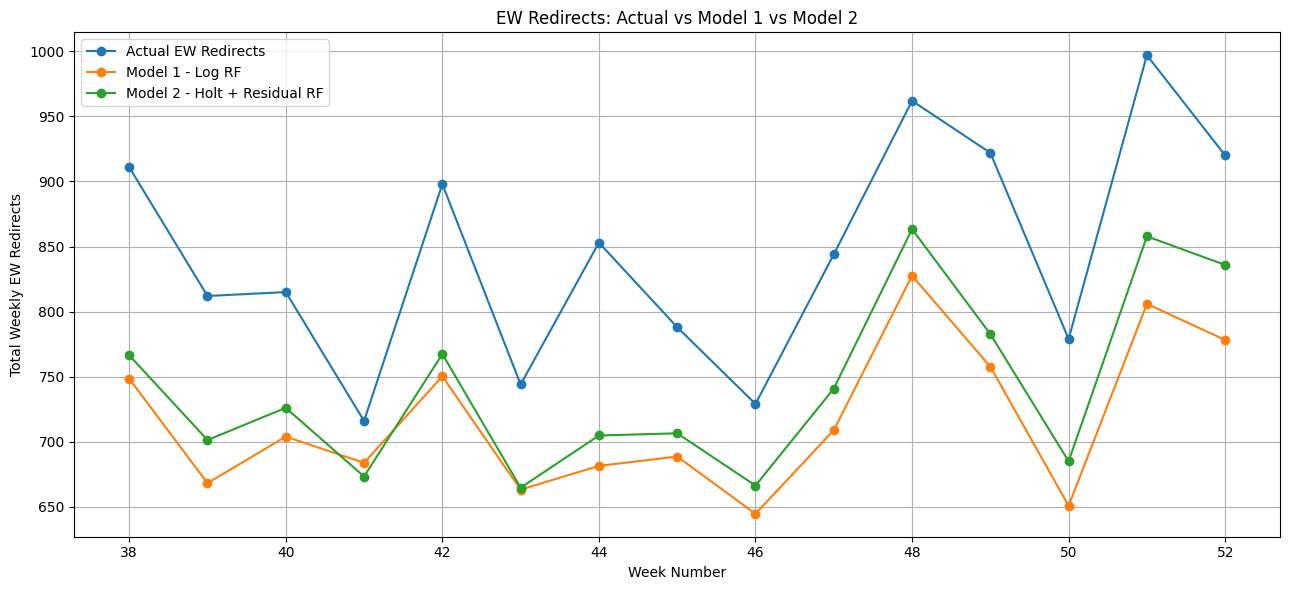


SAVED EW REDIRECT MODEL 2 FILES
- final_ew_redirect_test_predictions_model2_holt_residual.csv
- final_ew_redirect_weekly_predictions_model2_holt_residual.csv
- final_ew_redirect_row_metrics_model2_holt_residual.csv
- final_ew_redirect_weekly_metrics_model2_holt_residual.csv
- final_ew_redirect_residual_component_metrics_model2.csv
- final_ew_redirect_row_model_comparison.csv
- final_ew_redirect_weekly_model_comparison.csv

FINAL EW REDIRECT MODEL 2 SUMMARY
Model  : EW Redirect Model 2 - Holt + RF Residual
Target : Expected EW redirects
Target column used: NumberOfRedirects
Row MAE     : 1.5067
Row RMSE    : 1.9470
Row R2      : 0.1957
Weekly MAE  : 103.1702
Weekly RMSE : 107.6427
Weekly R2   : -0.6482


In [9]:
# ============================================================
# 19. BONUS MODEL 2: EW REDIRECT PREDICTION - HOLT + RF RESIDUAL
#
# Target:
#   Expected number of Eurowings redirects
#
# Model:
#   Model 2 = Holt weekly redirect trend + RF residual
#
# Formula:
#   final_log_redirect_pred =
#       HoltWeeklyRedirectTrendLog
#       +
#       RFResidualLogRedirect
#
# Important:
#   This does NOT replace Model 1.
#   This is an experiment to see whether trend + residual fixes
#   the weekly underprediction from simple Log RF.
# ============================================================


print("\n" + "=" * 80)
print("BONUS: EW REDIRECT MODEL 2 - HOLT + RF RESIDUAL")
print("=" * 80)


# =========================
# 19.1 Residual feature lists
# =========================

EW_REDIRECT_RESIDUAL_FEATURES = [
    col for col in BASE_FEATURES
    if col not in ["WeekNumber", "WeekSin", "WeekCos"]
]

EW_REDIRECT_RESIDUAL_CATEGORICAL_FEATURES = [
    col for col in CATEGORICAL_FEATURES
    if col in EW_REDIRECT_RESIDUAL_FEATURES
]

EW_REDIRECT_RESIDUAL_NUMERIC_FEATURES = [
    col for col in NUMERIC_FEATURES
    if col in EW_REDIRECT_RESIDUAL_FEATURES
]


# =========================
# 19.2 Leakage checks
# =========================

BAD_REDIRECT_RESIDUAL_FEATURES = {
    "Revenue",
    "LogRevenue",
    "RedirectsCount",
    "NumberOfRedirects",
    "LogRedirects",
    "Bookings",
    "BookingCount",
    "RedirectTrendLogPrediction",
    "RedirectResidualLog",
}

assert not any(col in BAD_REDIRECT_RESIDUAL_FEATURES for col in EW_REDIRECT_RESIDUAL_FEATURES), \
    "Leakage risk: target/outcome column found in EW redirect residual features."

missing_redirect_residual_features = [
    col for col in EW_REDIRECT_RESIDUAL_FEATURES
    if col not in redirect_df.columns
]

assert len(missing_redirect_residual_features) == 0, \
    f"Missing EW redirect residual features: {missing_redirect_residual_features}"

print("EW redirect residual leakage check passed.")
print("EW redirect residual features:")
print(EW_REDIRECT_RESIDUAL_FEATURES)


# =========================
# 19.3 Holt trend for weekly EW redirects
# =========================

def fit_holt_redirect_trend(train_part_df, pred_weeks):
    """
    Fit Holt damped trend on weekly mean log redirects.

    We use weekly mean LogRedirects, not total redirects,
    because the final model predicts row-level redirects.
    """

    train_start_week = int(train_part_df["WeekNumber"].min())
    train_end_week = int(train_part_df["WeekNumber"].max())

    train_week_index = list(range(train_start_week, train_end_week + 1))

    weekly_train_log_redirects = (
        train_part_df
        .groupby("WeekNumber")["LogRedirects"]
        .mean()
        .reindex(train_week_index)
        .interpolate()
        .ffill()
        .bfill()
    )

    holt_redirect_model = ExponentialSmoothing(
        weekly_train_log_redirects.values,
        trend="add",
        damped_trend=True,
        seasonal=None,
        initialization_method="estimated",
    ).fit(optimized=True)

    trend_train_log = pd.Series(
        holt_redirect_model.fittedvalues,
        index=train_week_index,
    )

    forecast_start_week = train_end_week + 1
    forecast_end_week = int(max(pred_weeks))
    forecast_week_index = list(range(forecast_start_week, forecast_end_week + 1))

    trend_pred_full_log = pd.Series(
        holt_redirect_model.forecast(len(forecast_week_index)),
        index=forecast_week_index,
    )

    trend_pred_log = trend_pred_full_log.reindex(pred_weeks)

    assert trend_pred_log.notna().all(), \
        "Some redirect Holt trend predictions are missing."

    return trend_train_log, trend_pred_log, holt_redirect_model


# =========================
# 19.4 Fit + predict Holt residual redirect model
# =========================

def fit_predict_ew_holt_residual_redirect_rf(
    train_part_df,
    pred_part_df,
    pred_weeks,
):
    """
    Train EW redirect Holt + RF residual model.

    Steps:
    1. Fit Holt trend on train weekly mean LogRedirects.
    2. Compute train residual:
       LogRedirects - Holt trend log.
    3. Train RF on residual.
    4. Predict:
       Holt trend log + RF residual log.
    5. Convert back with expm1.
    """

    train_part_df = train_part_df.copy()
    pred_part_df = pred_part_df.copy()

    trend_train_log, trend_pred_log, holt_redirect_model = fit_holt_redirect_trend(
        train_part_df=train_part_df,
        pred_weeks=pred_weeks,
    )

    train_part_df["RedirectTrendLogPrediction"] = train_part_df["WeekNumber"].map(
        trend_train_log
    )

    pred_part_df["RedirectTrendLogPrediction"] = pred_part_df["WeekNumber"].map(
        trend_pred_log
    )

    assert train_part_df["RedirectTrendLogPrediction"].notna().all(), \
        "Missing train redirect trend predictions."

    assert pred_part_df["RedirectTrendLogPrediction"].notna().all(), \
        "Missing test redirect trend predictions."

    train_part_df["RedirectResidualLog"] = (
        train_part_df["LogRedirects"]
        - train_part_df["RedirectTrendLogPrediction"]
    )

    residual_redirect_model = build_rf_pipeline(
        EW_REDIRECT_RESIDUAL_CATEGORICAL_FEATURES,
        EW_REDIRECT_RESIDUAL_NUMERIC_FEATURES,
        min_samples_leaf=5,
    )

    residual_redirect_model.fit(
        train_part_df[EW_REDIRECT_RESIDUAL_FEATURES],
        train_part_df["RedirectResidualLog"],
    )

    residual_pred_log = residual_redirect_model.predict(
        pred_part_df[EW_REDIRECT_RESIDUAL_FEATURES]
    )

    trend_pred_log_by_row = pred_part_df["RedirectTrendLogPrediction"].values

    final_log_pred = trend_pred_log_by_row + residual_pred_log
    final_redirect_pred = safe_expm1(final_log_pred)

    return {
        "final_log_pred": final_log_pred,
        "final_redirect_pred": final_redirect_pred,
        "trend_log_pred": trend_pred_log_by_row,
        "residual_log_pred": residual_pred_log,
        "holt_redirect_model": holt_redirect_model,
        "residual_redirect_model": residual_redirect_model,
    }


# =========================
# 19.5 Train Model 2
# =========================

print("\n" + "=" * 80)
print("TRAINING EW REDIRECT MODEL 2")
print("=" * 80)

ew_redirect_model2_parts = fit_predict_ew_holt_residual_redirect_rf(
    train_part_df=redirect_train_df,
    pred_part_df=redirect_test_df,
    pred_weeks=redirect_test_weeks,
)


# =========================
# 19.6 Build Model 2 prediction dataframe
# =========================

redirect_model2_output_cols = [
    "FlightWeek",
    "WeekNumber",
    REDIRECT_TARGET,
] + BASE_FEATURES

redirect_model2_output_cols = dedupe_columns(redirect_model2_output_cols)

ew_redirect_model2_predictions = redirect_test_df[
    redirect_model2_output_cols
].copy()

ew_redirect_model2_predictions = ew_redirect_model2_predictions.loc[
    :,
    ~ew_redirect_model2_predictions.columns.duplicated()
].copy()

ew_redirect_model2_predictions["ActualRedirects"] = redirect_test_df[REDIRECT_TARGET].values

ew_redirect_model2_predictions["Pred_HoltResidualRF_Redirects"] = (
    ew_redirect_model2_parts["final_redirect_pred"]
)

ew_redirect_model2_predictions["LogPred_HoltResidualRF_Redirects"] = (
    ew_redirect_model2_parts["final_log_pred"]
)

ew_redirect_model2_predictions["HoltRedirectTrendLogPred"] = (
    ew_redirect_model2_parts["trend_log_pred"]
)

ew_redirect_model2_predictions["HoltRedirectResidualLogPred"] = (
    ew_redirect_model2_parts["residual_log_pred"]
)

ew_redirect_model2_predictions["ActualHoltRedirectResidualLog"] = (
    redirect_test_df["LogRedirects"].values
    - ew_redirect_model2_predictions["HoltRedirectTrendLogPred"]
)

ew_redirect_model2_predictions["RedirectError"] = (
    ew_redirect_model2_predictions["ActualRedirects"]
    - ew_redirect_model2_predictions["Pred_HoltResidualRF_Redirects"]
)

ew_redirect_model2_predictions["AbsRedirectError"] = np.abs(
    ew_redirect_model2_predictions["RedirectError"]
)


# =========================
# 19.7 Row-level metrics
# =========================

ew_redirect_model2_metrics = []

ew_redirect_model2_metrics.append(
    evaluate_model(
        "Test: EW Redirect Model 2 - Holt + Residual RF Row Level",
        ew_redirect_model2_predictions["ActualRedirects"],
        ew_redirect_model2_predictions["Pred_HoltResidualRF_Redirects"],
    )
)

ew_redirect_model2_metrics_df = pd.DataFrame(ew_redirect_model2_metrics)

print("\n" + "=" * 80)
print("EW REDIRECT MODEL 2 ROW-LEVEL METRICS")
print("=" * 80)
print(ew_redirect_model2_metrics_df.to_string(index=False))


# =========================
# 19.8 Residual component metrics
# =========================

ew_redirect_residual_component_metrics = []

ew_redirect_residual_component_metrics.append(
    evaluate_model(
        "Test: EW Redirect Model 2 - RF Residual Component Log Scale",
        ew_redirect_model2_predictions["ActualHoltRedirectResidualLog"],
        ew_redirect_model2_predictions["HoltRedirectResidualLogPred"],
    )
)

ew_redirect_residual_component_metrics_df = pd.DataFrame(
    ew_redirect_residual_component_metrics
)


# =========================
# 19.9 Weekly aggregate metrics
# =========================

ew_redirect_model2_weekly = (
    ew_redirect_model2_predictions
    .groupby(["FlightWeek", "WeekNumber"], as_index=False)
    .agg(
        ActualWeeklyRedirects=("ActualRedirects", "sum"),
        PredWeeklyRedirects=("Pred_HoltResidualRF_Redirects", "sum"),
        Rows=("ActualRedirects", "size"),
        RowMAE=("AbsRedirectError", "mean"),
    )
    .sort_values("WeekNumber")
)

ew_redirect_model2_weekly["WeeklyError"] = (
    ew_redirect_model2_weekly["ActualWeeklyRedirects"]
    - ew_redirect_model2_weekly["PredWeeklyRedirects"]
)

ew_redirect_model2_weekly["AbsWeeklyError"] = np.abs(
    ew_redirect_model2_weekly["WeeklyError"]
)

ew_redirect_model2_weekly_metrics = []

ew_redirect_model2_weekly_metrics.append(
    evaluate_model(
        "Test: EW Redirect Model 2 - Holt + Residual RF Weekly Aggregate",
        ew_redirect_model2_weekly["ActualWeeklyRedirects"],
        ew_redirect_model2_weekly["PredWeeklyRedirects"],
    )
)

ew_redirect_model2_weekly_metrics_df = pd.DataFrame(
    ew_redirect_model2_weekly_metrics
)

print("\n" + "=" * 80)
print("EW REDIRECT MODEL 2 WEEKLY TEST COMPARISON")
print("=" * 80)
print(ew_redirect_model2_weekly.to_string(index=False))


# =========================
# 19.10 Compare Model 1 vs Model 2
# =========================

ew_redirect_row_model_comparison = pd.concat(
    [
        ew_redirect_metrics_df,
        ew_redirect_model2_metrics_df,
    ],
    ignore_index=True,
)

ew_redirect_weekly_model_comparison = pd.concat(
    [
        weekly_redirect_metrics_df,
        ew_redirect_model2_weekly_metrics_df,
    ],
    ignore_index=True,
)

print("\n" + "=" * 80)
print("EW REDIRECT ROW-LEVEL MODEL COMPARISON")
print("=" * 80)
print(
    ew_redirect_row_model_comparison
    .sort_values("MAE")
    .to_string(index=False)
)

print("\n" + "=" * 80)
print("EW REDIRECT WEEKLY MODEL COMPARISON")
print("=" * 80)
print(
    ew_redirect_weekly_model_comparison
    .sort_values("MAE")
    .to_string(index=False)
)


# =========================
# 19.11 Plot weekly actual vs Model 1 vs Model 2
# =========================

plt.figure(figsize=(13, 6))

plt.plot(
    ew_redirect_model2_weekly["WeekNumber"],
    ew_redirect_model2_weekly["ActualWeeklyRedirects"],
    marker="o",
    label="Actual EW Redirects",
)

plt.plot(
    ew_redirect_weekly["WeekNumber"],
    ew_redirect_weekly["PredWeeklyRedirects"],
    marker="o",
    label="Model 1 - Log RF",
)

plt.plot(
    ew_redirect_model2_weekly["WeekNumber"],
    ew_redirect_model2_weekly["PredWeeklyRedirects"],
    marker="o",
    label="Model 2 - Holt + Residual RF",
)

plt.xlabel("Week Number")
plt.ylabel("Total Weekly EW Redirects")
plt.title("EW Redirects: Actual vs Model 1 vs Model 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================
# 19.12 Save EW redirect Model 2 outputs
# =========================

ew_redirect_model2_predictions.to_csv(
    "final_ew_redirect_test_predictions_model2_holt_residual.csv",
    index=False,
)

ew_redirect_model2_weekly.to_csv(
    "final_ew_redirect_weekly_predictions_model2_holt_residual.csv",
    index=False,
)

ew_redirect_model2_metrics_df.to_csv(
    "final_ew_redirect_row_metrics_model2_holt_residual.csv",
    index=False,
)

ew_redirect_model2_weekly_metrics_df.to_csv(
    "final_ew_redirect_weekly_metrics_model2_holt_residual.csv",
    index=False,
)

ew_redirect_residual_component_metrics_df.to_csv(
    "final_ew_redirect_residual_component_metrics_model2.csv",
    index=False,
)

ew_redirect_row_model_comparison.to_csv(
    "final_ew_redirect_row_model_comparison.csv",
    index=False,
)

ew_redirect_weekly_model_comparison.to_csv(
    "final_ew_redirect_weekly_model_comparison.csv",
    index=False,
)

print("\n" + "=" * 80)
print("SAVED EW REDIRECT MODEL 2 FILES")
print("=" * 80)
print("- final_ew_redirect_test_predictions_model2_holt_residual.csv")
print("- final_ew_redirect_weekly_predictions_model2_holt_residual.csv")
print("- final_ew_redirect_row_metrics_model2_holt_residual.csv")
print("- final_ew_redirect_weekly_metrics_model2_holt_residual.csv")
print("- final_ew_redirect_residual_component_metrics_model2.csv")
print("- final_ew_redirect_row_model_comparison.csv")
print("- final_ew_redirect_weekly_model_comparison.csv")


# =========================
# 19.13 Final Model 2 summary
# =========================

best_model2_row = ew_redirect_model2_metrics_df.iloc[0]
best_model2_weekly = ew_redirect_model2_weekly_metrics_df.iloc[0]

print("\n" + "=" * 80)
print("FINAL EW REDIRECT MODEL 2 SUMMARY")
print("=" * 80)
print("Model  : EW Redirect Model 2 - Holt + RF Residual")
print("Target : Expected EW redirects")
print(f"Target column used: {REDIRECT_TARGET}")
print(f"Row MAE     : {best_model2_row['MAE']:.4f}")
print(f"Row RMSE    : {best_model2_row['RMSE']:.4f}")
print(f"Row R2      : {best_model2_row['R2']:.4f}")
print(f"Weekly MAE  : {best_model2_weekly['MAE']:.4f}")
print(f"Weekly RMSE : {best_model2_weekly['RMSE']:.4f}")
print(f"Weekly R2   : {best_model2_weekly['R2']:.4f}")


BONUS: EW REDIRECT MODEL 4 - HOLT + RESIDUAL + FALLBACK COMPETITOR FEATURES
Model 4 fallback market keys:
Level 1: ['FlightWeek', 'WeekNumber', 'Route', 'TripType', 'CabinClass']
Level 2: ['FlightWeek', 'WeekNumber', 'Route', 'CabinClass']
Level 3: ['FlightWeek', 'WeekNumber', 'Route']

Model 4 competitor coverage:
Train EW rows with competitor: 8236 / 9689
Test EW rows with competitor: 2423 / 3895

Train match level counts:
CompetitorMatchLevel
exact_week_route_trip_cabin    5340
fallback_week_route_cabin      1499
none                           1453
fallback_week_route            1397
Name: count, dtype: int64

Test match level counts:
CompetitorMatchLevel
exact_week_route_trip_cabin    1553
none                           1472
fallback_week_route_cabin       468
fallback_week_route             402
Name: count, dtype: int64

Model 4 residual features:
['Route', 'CountryRoute', 'OriginAirport', 'OriginCountry', 'DestinationAirport', 'DestinationCountry', 'MainAirlineCarrier', 'IsConne

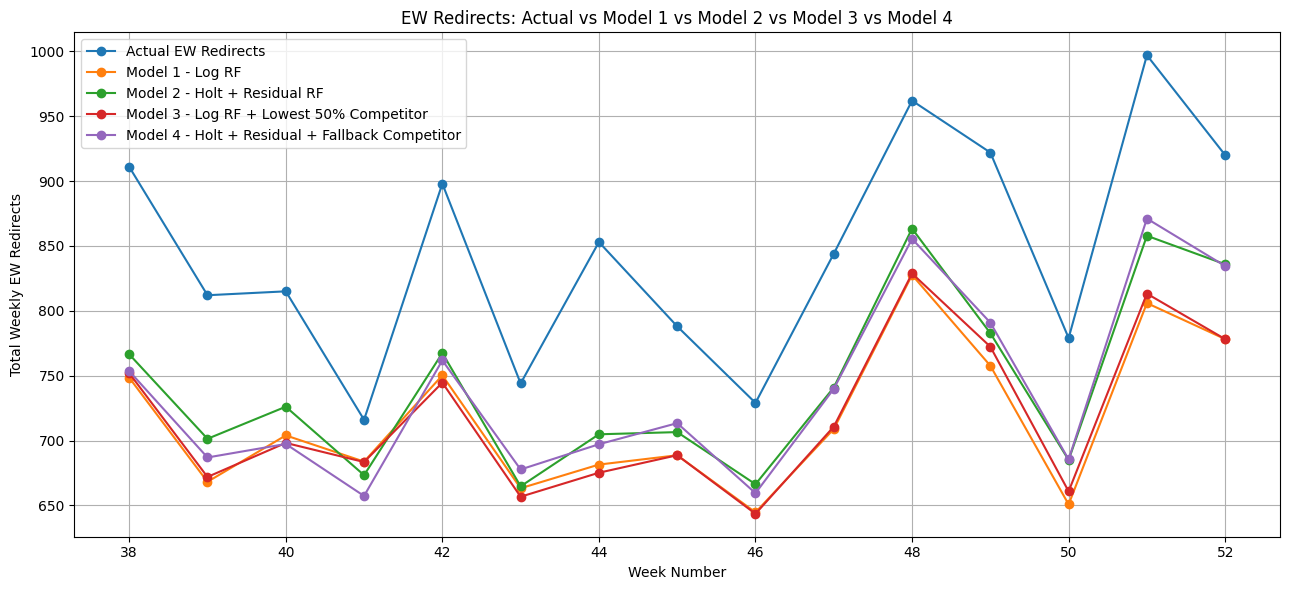


SAVED EW REDIRECT MODEL 4 FILES
- final_ew_redirect_test_predictions_model4_holt_residual_fallback_competitor.csv
- final_ew_redirect_weekly_predictions_model4_holt_residual_fallback_competitor.csv
- final_ew_redirect_row_metrics_model4_holt_residual_fallback_competitor.csv
- final_ew_redirect_weekly_metrics_model4_holt_residual_fallback_competitor.csv
- final_ew_redirect_residual_component_metrics_model4.csv
- final_ew_redirect_row_model_comparison_1234.csv
- final_ew_redirect_weekly_model_comparison_1234.csv

FINAL EW REDIRECT MODEL 4 SUMMARY
Model  : EW Redirect Model 4 - Holt + RF Residual + Fallback Competitor Features
Target : Expected EW redirects
Target column used: NumberOfRedirects
Row MAE     : 1.4800
Row RMSE    : 1.9170
Row R2      : 0.2203
Weekly MAE  : 107.2369
Weekly RMSE : 111.5789
Weekly R2   : -0.7709


In [ ]:
# ============================================================
# 21. BONUS MODEL 4:
#     EW REDIRECT HOLT + RF RESIDUAL
#     + FALLBACK COMPETITOR MATCHING
#     + LOWEST 50% COMPETITOR GAP/RATIO FEATURES
#
# Why:
#   Model 2 improved weekly forecast using Holt trend.
#   Model 3 improved row-level forecast slightly using competitor price features.
#   Model 4 combines both.
#
# Leakage rule:
#   Train competitor features use actual competitor Revenue from train weeks.
#   Test competitor features use predicted competitor prices from final price model.
#
# Fallback competitor matching:
#   Level 1: FlightWeek + WeekNumber + Route + TripType + CabinClass
#   Level 2: FlightWeek + WeekNumber + Route + CabinClass
#   Level 3: FlightWeek + WeekNumber + Route
#
# Same direction is preserved through Route = OriginAirport_DestinationAirport.
# ============================================================


print("\n" + "=" * 80)
print("BONUS: EW REDIRECT MODEL 4 - HOLT + RESIDUAL + FALLBACK COMPETITOR FEATURES")
print("=" * 80)


# =========================
# 21.1 Safety checks
# =========================

assert "fit_holt_redirect_trend" in globals(), (
    "fit_holt_redirect_trend not found. Run Model 2 block first."
)

assert "test_point_df" in globals(), (
    "test_point_df not found. Run competitor price model first."
)

assert "Pred_WeightedEnsemble" in test_point_df.columns, (
    "Pred_WeightedEnsemble not found in test_point_df. "
    "Run final competitor price model first."
)


# =========================
# 21.2 Helper: average cheapest 50%
# =========================

def avg_lowest_50pct_model4(values):
    """
    Sort competitor prices low to high.
    Take cheapest 50% of competitor offers.
    """
    values = pd.Series(values).dropna().sort_values()

    if len(values) == 0:
        return np.nan

    n_take = int(np.ceil(len(values) * 0.50))
    n_take = max(1, n_take)

    return values.iloc[:n_take].mean()


# =========================
# 21.3 Helper: build competitor features
# =========================

MODEL4_COMPETITOR_NUMERIC_FEATURES = [
    "CompetitorOfferCount",
    "CompetitorAirlineCount",
    "CheapestCompetitorRevenue",
    "AvgCompetitorRevenue",
    "AvgLowest50PctCompetitorRevenue",
]

def build_competitor_feature_table(source_df, keys, price_col):
    """
    Build competitor market features at a given key level.
    """
    out = (
        source_df
        .groupby(keys)
        .agg(
            CompetitorOfferCount=("MainAirlineCarrier", "size"),
            CompetitorAirlineCount=("MainAirlineCarrier", "nunique"),
            CheapestCompetitorRevenue=(price_col, "min"),
            AvgCompetitorRevenue=(price_col, "mean"),
            AvgLowest50PctCompetitorRevenue=(
                price_col,
                avg_lowest_50pct_model4,
            ),
        )
        .reset_index()
    )

    return out


def merge_competitor_features_with_fallback(ew_df, feature_levels):
    """
    Merge competitor features into EW rows using fallback levels.

    feature_levels:
        list of tuples:
        (level_name, keys, competitor_feature_df)
    """
    out = ew_df.copy().reset_index(drop=True)
    out["_row_id"] = np.arange(len(out))

    for col in MODEL4_COMPETITOR_NUMERIC_FEATURES:
        out[col] = np.nan

    out["CompetitorMatchLevel"] = "none"

    for level_name, keys, feature_df in feature_levels:
        tmp = (
            out[["_row_id"] + keys]
            .merge(feature_df, on=keys, how="left")
            .sort_values("_row_id")
            .set_index("_row_id")
        )

        tmp = tmp.reindex(out["_row_id"])

        needs_fill = out["CompetitorOfferCount"].isna()
        has_match = tmp["CompetitorOfferCount"].notna().values
        fill_mask = needs_fill & has_match

        for col in MODEL4_COMPETITOR_NUMERIC_FEATURES:
            out.loc[fill_mask, col] = tmp.loc[fill_mask, col].values

        out.loc[fill_mask, "CompetitorMatchLevel"] = level_name

    out = out.drop(columns=["_row_id"])

    return out


# =========================
# 21.4 Rebuild full market dataframe
# =========================

model4_market_df = pd.read_csv(DATA_PATH).copy()

model4_market_df["Revenue"] = pd.to_numeric(
    model4_market_df["Revenue"],
    errors="coerce",
)

model4_market_df = model4_market_df.dropna(
    subset=[
        "Revenue",
        "FlightWeek",
        "MainAirlineCarrier",
    ]
).copy()

model4_market_df["WeekNumber"] = (
    model4_market_df["FlightWeek"]
    .astype(str)
    .str.extract(r"W(\d+)")
    .astype(int)
)

model4_market_df["Route"] = (
    model4_market_df["OriginAirport"].astype(str)
    + "_"
    + model4_market_df["DestinationAirport"].astype(str)
)

model4_market_df["CountryRoute"] = (
    model4_market_df["OriginCountry"].astype(str)
    + "_"
    + model4_market_df["DestinationCountry"].astype(str)
)

model4_market_df["WeekSin"] = np.sin(
    2 * np.pi * model4_market_df["WeekNumber"] / 52
)

model4_market_df["WeekCos"] = np.cos(
    2 * np.pi * model4_market_df["WeekNumber"] / 52
)


# =========================
# 21.5 Define fallback market keys
# =========================

MODEL4_MARKET_KEYS_LEVEL_1 = [
    "FlightWeek",
    "WeekNumber",
    "Route",
    "TripType",
    "CabinClass",
]

MODEL4_MARKET_KEYS_LEVEL_2 = [
    "FlightWeek",
    "WeekNumber",
    "Route",
    "CabinClass",
]

MODEL4_MARKET_KEYS_LEVEL_3 = [
    "FlightWeek",
    "WeekNumber",
    "Route",
]

print("Model 4 fallback market keys:")
print("Level 1:", MODEL4_MARKET_KEYS_LEVEL_1)
print("Level 2:", MODEL4_MARKET_KEYS_LEVEL_2)
print("Level 3:", MODEL4_MARKET_KEYS_LEVEL_3)


# =========================
# 21.6 Competitor source for train weeks
# =========================

model4_competitor_train = model4_market_df[
    (model4_market_df["MainAirlineCarrier"].astype(str).str.upper() != "EW")
    & (model4_market_df["WeekNumber"].between(1, REDIRECT_TRAIN_END_WEEK))
].copy()

model4_competitor_train["CompetitorPriceForMarket"] = (
    model4_competitor_train["Revenue"]
)

train_features_l1 = build_competitor_feature_table(
    model4_competitor_train,
    MODEL4_MARKET_KEYS_LEVEL_1,
    "CompetitorPriceForMarket",
)

train_features_l2 = build_competitor_feature_table(
    model4_competitor_train,
    MODEL4_MARKET_KEYS_LEVEL_2,
    "CompetitorPriceForMarket",
)

train_features_l3 = build_competitor_feature_table(
    model4_competitor_train,
    MODEL4_MARKET_KEYS_LEVEL_3,
    "CompetitorPriceForMarket",
)


# =========================
# 21.7 Competitor source for test weeks
# =========================

model4_competitor_test = test_point_df.copy()

model4_competitor_test["CompetitorPriceForMarket"] = (
    model4_competitor_test["Pred_WeightedEnsemble"]
)

test_features_l1 = build_competitor_feature_table(
    model4_competitor_test,
    MODEL4_MARKET_KEYS_LEVEL_1,
    "CompetitorPriceForMarket",
)

test_features_l2 = build_competitor_feature_table(
    model4_competitor_test,
    MODEL4_MARKET_KEYS_LEVEL_2,
    "CompetitorPriceForMarket",
)

test_features_l3 = build_competitor_feature_table(
    model4_competitor_test,
    MODEL4_MARKET_KEYS_LEVEL_3,
    "CompetitorPriceForMarket",
)


# =========================
# 21.8 Merge fallback competitor features into EW train/test
# =========================

model4_train_levels = [
    ("exact_week_route_trip_cabin", MODEL4_MARKET_KEYS_LEVEL_1, train_features_l1),
    ("fallback_week_route_cabin", MODEL4_MARKET_KEYS_LEVEL_2, train_features_l2),
    ("fallback_week_route", MODEL4_MARKET_KEYS_LEVEL_3, train_features_l3),
]

model4_test_levels = [
    ("exact_week_route_trip_cabin", MODEL4_MARKET_KEYS_LEVEL_1, test_features_l1),
    ("fallback_week_route_cabin", MODEL4_MARKET_KEYS_LEVEL_2, test_features_l2),
    ("fallback_week_route", MODEL4_MARKET_KEYS_LEVEL_3, test_features_l3),
]

redirect_train_model4_df = merge_competitor_features_with_fallback(
    redirect_train_df,
    model4_train_levels,
)

redirect_test_model4_df = merge_competitor_features_with_fallback(
    redirect_test_df,
    model4_test_levels,
)


# =========================
# 21.9 Add competitor exists + EW gap/ratio features
# =========================

MODEL4_PRICE_COMPARISON_FEATURES = [
    "CompetitorExists",
    "EW_Gap_vs_CheapestCompetitor",
    "EW_Gap_vs_AvgCompetitor",
    "EW_Gap_vs_Lowest50PctCompetitor",
    "EW_Ratio_vs_CheapestCompetitor",
    "EW_Ratio_vs_AvgCompetitor",
    "EW_Ratio_vs_Lowest50PctCompetitor",
]

for part_df in [redirect_train_model4_df, redirect_test_model4_df]:
    part_df["Revenue"] = pd.to_numeric(
        part_df["Revenue"],
        errors="coerce",
    )

    part_df["CompetitorExists"] = (
        part_df["CompetitorOfferCount"].fillna(0) > 0
    ).astype(int)

    part_df["CompetitorOfferCount"] = (
        part_df["CompetitorOfferCount"]
        .fillna(0)
        .astype(int)
    )

    part_df["CompetitorAirlineCount"] = (
        part_df["CompetitorAirlineCount"]
        .fillna(0)
        .astype(int)
    )

    part_df["EW_Gap_vs_CheapestCompetitor"] = (
        part_df["Revenue"]
        - part_df["CheapestCompetitorRevenue"]
    )

    part_df["EW_Gap_vs_AvgCompetitor"] = (
        part_df["Revenue"]
        - part_df["AvgCompetitorRevenue"]
    )

    part_df["EW_Gap_vs_Lowest50PctCompetitor"] = (
        part_df["Revenue"]
        - part_df["AvgLowest50PctCompetitorRevenue"]
    )

    part_df["EW_Ratio_vs_CheapestCompetitor"] = np.where(
        part_df["CheapestCompetitorRevenue"] > 0,
        part_df["Revenue"] / part_df["CheapestCompetitorRevenue"],
        np.nan,
    )

    part_df["EW_Ratio_vs_AvgCompetitor"] = np.where(
        part_df["AvgCompetitorRevenue"] > 0,
        part_df["Revenue"] / part_df["AvgCompetitorRevenue"],
        np.nan,
    )

    part_df["EW_Ratio_vs_Lowest50PctCompetitor"] = np.where(
        part_df["AvgLowest50PctCompetitorRevenue"] > 0,
        part_df["Revenue"] / part_df["AvgLowest50PctCompetitorRevenue"],
        np.nan,
    )


print("\nModel 4 competitor coverage:")
print(
    "Train EW rows with competitor:",
    redirect_train_model4_df["CompetitorExists"].sum(),
    "/",
    len(redirect_train_model4_df),
)

print(
    "Test EW rows with competitor:",
    redirect_test_model4_df["CompetitorExists"].sum(),
    "/",
    len(redirect_test_model4_df),
)

print("\nTrain match level counts:")
print(redirect_train_model4_df["CompetitorMatchLevel"].value_counts(dropna=False))

print("\nTest match level counts:")
print(redirect_test_model4_df["CompetitorMatchLevel"].value_counts(dropna=False))


# =========================
# 21.10 Model 4 feature lists
# =========================

MODEL4_MARKET_NUMERIC_FEATURES = (
    MODEL4_COMPETITOR_NUMERIC_FEATURES
    + MODEL4_PRICE_COMPARISON_FEATURES
)

MODEL4_MARKET_CATEGORICAL_FEATURES = [
    "CompetitorMatchLevel",
]

EW_REDIRECT_MODEL4_RESIDUAL_FEATURES = (
    [
        col for col in BASE_FEATURES
        if col not in ["WeekNumber", "WeekSin", "WeekCos"]
    ]
    + MODEL4_MARKET_NUMERIC_FEATURES
    + MODEL4_MARKET_CATEGORICAL_FEATURES
)

EW_REDIRECT_MODEL4_RESIDUAL_CATEGORICAL_FEATURES = (
    [
        col for col in CATEGORICAL_FEATURES
        if col in EW_REDIRECT_MODEL4_RESIDUAL_FEATURES
    ]
    + MODEL4_MARKET_CATEGORICAL_FEATURES
)

EW_REDIRECT_MODEL4_RESIDUAL_NUMERIC_FEATURES = (
    [
        col for col in NUMERIC_FEATURES
        if col in EW_REDIRECT_MODEL4_RESIDUAL_FEATURES
    ]
    + MODEL4_MARKET_NUMERIC_FEATURES
)

EW_REDIRECT_MODEL4_RESIDUAL_FEATURES = dedupe_columns(
    EW_REDIRECT_MODEL4_RESIDUAL_FEATURES
)

EW_REDIRECT_MODEL4_RESIDUAL_CATEGORICAL_FEATURES = dedupe_columns(
    EW_REDIRECT_MODEL4_RESIDUAL_CATEGORICAL_FEATURES
)

EW_REDIRECT_MODEL4_RESIDUAL_NUMERIC_FEATURES = dedupe_columns(
    EW_REDIRECT_MODEL4_RESIDUAL_NUMERIC_FEATURES
)

missing_model4_train_features = [
    col for col in EW_REDIRECT_MODEL4_RESIDUAL_FEATURES
    if col not in redirect_train_model4_df.columns
]

missing_model4_test_features = [
    col for col in EW_REDIRECT_MODEL4_RESIDUAL_FEATURES
    if col not in redirect_test_model4_df.columns
]

assert len(missing_model4_train_features) == 0, \
    f"Missing Model 4 train features: {missing_model4_train_features}"

assert len(missing_model4_test_features) == 0, \
    f"Missing Model 4 test features: {missing_model4_test_features}"

BAD_MODEL4_FEATURES = {
    "RedirectsCount",
    "NumberOfRedirects",
    "LogRedirects",
    "Bookings",
    "BookingCount",
    "RedirectTrendLogPrediction",
    "RedirectResidualLog",
}

assert not any(col in BAD_MODEL4_FEATURES for col in EW_REDIRECT_MODEL4_RESIDUAL_FEATURES), \
    "Leakage risk: target column found in Model 4 features."

print("\nModel 4 residual features:")
print(EW_REDIRECT_MODEL4_RESIDUAL_FEATURES)


# =========================
# 21.11 Fit + predict Model 4
# =========================

def fit_predict_ew_holt_residual_redirect_rf_model4(
    train_part_df,
    pred_part_df,
    pred_weeks,
):
    """
    Model 4:
    Holt weekly redirect trend + RF residual with competitor features.
    """

    train_part_df = train_part_df.copy()
    pred_part_df = pred_part_df.copy()

    trend_train_log, trend_pred_log, holt_redirect_model = fit_holt_redirect_trend(
        train_part_df=train_part_df,
        pred_weeks=pred_weeks,
    )

    train_part_df["RedirectTrendLogPrediction"] = train_part_df["WeekNumber"].map(
        trend_train_log
    )

    pred_part_df["RedirectTrendLogPrediction"] = pred_part_df["WeekNumber"].map(
        trend_pred_log
    )

    assert train_part_df["RedirectTrendLogPrediction"].notna().all(), \
        "Missing train redirect trend predictions."

    assert pred_part_df["RedirectTrendLogPrediction"].notna().all(), \
        "Missing test redirect trend predictions."

    train_part_df["RedirectResidualLog"] = (
        train_part_df["LogRedirects"]
        - train_part_df["RedirectTrendLogPrediction"]
    )

    residual_redirect_model = build_rf_pipeline(
        EW_REDIRECT_MODEL4_RESIDUAL_CATEGORICAL_FEATURES,
        EW_REDIRECT_MODEL4_RESIDUAL_NUMERIC_FEATURES,
        min_samples_leaf=5,
    )

    residual_redirect_model.fit(
        train_part_df[EW_REDIRECT_MODEL4_RESIDUAL_FEATURES],
        train_part_df["RedirectResidualLog"],
    )

    residual_pred_log = residual_redirect_model.predict(
        pred_part_df[EW_REDIRECT_MODEL4_RESIDUAL_FEATURES]
    )

    trend_pred_log_by_row = pred_part_df["RedirectTrendLogPrediction"].values

    final_log_pred = trend_pred_log_by_row + residual_pred_log
    final_redirect_pred = safe_expm1(final_log_pred)

    return {
        "final_log_pred": final_log_pred,
        "final_redirect_pred": final_redirect_pred,
        "trend_log_pred": trend_pred_log_by_row,
        "residual_log_pred": residual_pred_log,
        "holt_redirect_model": holt_redirect_model,
        "residual_redirect_model": residual_redirect_model,
    }


print("\n" + "=" * 80)
print("TRAINING EW REDIRECT MODEL 4")
print("=" * 80)

ew_redirect_model4_parts = fit_predict_ew_holt_residual_redirect_rf_model4(
    train_part_df=redirect_train_model4_df,
    pred_part_df=redirect_test_model4_df,
    pred_weeks=redirect_test_weeks,
)


# =========================
# 21.12 Build Model 4 prediction dataframe
# =========================

model4_output_cols = [
    "FlightWeek",
    "WeekNumber",
    REDIRECT_TARGET,
    "Revenue",
] + EW_REDIRECT_MODEL4_RESIDUAL_FEATURES

model4_output_cols = dedupe_columns(model4_output_cols)

ew_redirect_model4_predictions = redirect_test_model4_df[
    model4_output_cols
].copy()

ew_redirect_model4_predictions = ew_redirect_model4_predictions.loc[
    :,
    ~ew_redirect_model4_predictions.columns.duplicated()
].copy()

ew_redirect_model4_predictions["ActualRedirects"] = redirect_test_model4_df[
    REDIRECT_TARGET
].values

ew_redirect_model4_predictions["Pred_HoltResidualRF_CompetitorFeatures"] = (
    ew_redirect_model4_parts["final_redirect_pred"]
)

ew_redirect_model4_predictions["LogPred_HoltResidualRF_CompetitorFeatures"] = (
    ew_redirect_model4_parts["final_log_pred"]
)

ew_redirect_model4_predictions["HoltRedirectTrendLogPred"] = (
    ew_redirect_model4_parts["trend_log_pred"]
)

ew_redirect_model4_predictions["HoltRedirectResidualLogPred"] = (
    ew_redirect_model4_parts["residual_log_pred"]
)

ew_redirect_model4_predictions["ActualHoltRedirectResidualLog"] = (
    redirect_test_model4_df["LogRedirects"].values
    - ew_redirect_model4_predictions["HoltRedirectTrendLogPred"]
)

ew_redirect_model4_predictions["RedirectError"] = (
    ew_redirect_model4_predictions["ActualRedirects"]
    - ew_redirect_model4_predictions["Pred_HoltResidualRF_CompetitorFeatures"]
)

ew_redirect_model4_predictions["AbsRedirectError"] = np.abs(
    ew_redirect_model4_predictions["RedirectError"]
)


# =========================
# 21.13 Row-level metrics
# =========================

ew_redirect_model4_metrics = []

ew_redirect_model4_metrics.append(
    evaluate_model(
        "Test: EW Redirect Model 4 - Holt + Residual RF + Fallback Competitor Features Row Level",
        ew_redirect_model4_predictions["ActualRedirects"],
        ew_redirect_model4_predictions["Pred_HoltResidualRF_CompetitorFeatures"],
    )
)

ew_redirect_model4_metrics_df = pd.DataFrame(ew_redirect_model4_metrics)


# =========================
# 21.14 Residual component metrics
# =========================

ew_redirect_model4_residual_component_metrics = []

ew_redirect_model4_residual_component_metrics.append(
    evaluate_model(
        "Test: EW Redirect Model 4 - RF Residual Component Log Scale",
        ew_redirect_model4_predictions["ActualHoltRedirectResidualLog"],
        ew_redirect_model4_predictions["HoltRedirectResidualLogPred"],
    )
)

ew_redirect_model4_residual_component_metrics_df = pd.DataFrame(
    ew_redirect_model4_residual_component_metrics
)


# =========================
# 21.15 Weekly aggregate metrics
# =========================

ew_redirect_model4_weekly = (
    ew_redirect_model4_predictions
    .groupby(["FlightWeek", "WeekNumber"], as_index=False)
    .agg(
        ActualWeeklyRedirects=("ActualRedirects", "sum"),
        PredWeeklyRedirects=("Pred_HoltResidualRF_CompetitorFeatures", "sum"),
        Rows=("ActualRedirects", "size"),
        RowMAE=("AbsRedirectError", "mean"),
    )
    .sort_values("WeekNumber")
)

ew_redirect_model4_weekly["WeeklyError"] = (
    ew_redirect_model4_weekly["ActualWeeklyRedirects"]
    - ew_redirect_model4_weekly["PredWeeklyRedirects"]
)

ew_redirect_model4_weekly["AbsWeeklyError"] = np.abs(
    ew_redirect_model4_weekly["WeeklyError"]
)

ew_redirect_model4_weekly_metrics = []

ew_redirect_model4_weekly_metrics.append(
    evaluate_model(
        "Test: EW Redirect Model 4 - Holt + Residual RF + Fallback Competitor Features Weekly Aggregate",
        ew_redirect_model4_weekly["ActualWeeklyRedirects"],
        ew_redirect_model4_weekly["PredWeeklyRedirects"],
    )
)

ew_redirect_model4_weekly_metrics_df = pd.DataFrame(
    ew_redirect_model4_weekly_metrics
)

print("\n" + "=" * 80)
print("EW REDIRECT MODEL 4 WEEKLY TEST COMPARISON")
print("=" * 80)
print(ew_redirect_model4_weekly.to_string(index=False))


# =========================
# 21.16 Compare Model 1 vs 2 vs 3 vs 4
# =========================

ew_redirect_row_model_comparison_1234 = pd.concat(
    [
        ew_redirect_metrics_df,
        ew_redirect_model2_metrics_df,
        ew_redirect_model3_metrics_df,
        ew_redirect_model4_metrics_df,
    ],
    ignore_index=True,
)

ew_redirect_weekly_model_comparison_1234 = pd.concat(
    [
        weekly_redirect_metrics_df,
        ew_redirect_model2_weekly_metrics_df,
        ew_redirect_model3_weekly_metrics_df,
        ew_redirect_model4_weekly_metrics_df,
    ],
    ignore_index=True,
)

print("\n" + "=" * 80)
print("EW REDIRECT ROW-LEVEL MODEL COMPARISON 1 VS 2 VS 3 VS 4")
print("=" * 80)
print(
    ew_redirect_row_model_comparison_1234
    .sort_values("MAE")
    .to_string(index=False)
)

print("\n" + "=" * 80)
print("EW REDIRECT WEEKLY MODEL COMPARISON 1 VS 2 VS 3 VS 4")
print("=" * 80)
print(
    ew_redirect_weekly_model_comparison_1234
    .sort_values("MAE")
    .to_string(index=False)
)


# =========================
# 21.17 Plot actual vs all models
# =========================

plt.figure(figsize=(13, 6))

plt.plot(
    ew_redirect_model4_weekly["WeekNumber"],
    ew_redirect_model4_weekly["ActualWeeklyRedirects"],
    marker="o",
    label="Actual EW Redirects",
)

plt.plot(
    ew_redirect_weekly["WeekNumber"],
    ew_redirect_weekly["PredWeeklyRedirects"],
    marker="o",
    label="Model 1 - Log RF",
)

plt.plot(
    ew_redirect_model2_weekly["WeekNumber"],
    ew_redirect_model2_weekly["PredWeeklyRedirects"],
    marker="o",
    label="Model 2 - Holt + Residual RF",
)

plt.plot(
    ew_redirect_model3_weekly["WeekNumber"],
    ew_redirect_model3_weekly["PredWeeklyRedirects"],
    marker="o",
    label="Model 3 - Log RF + Lowest 50% Competitor",
)

plt.plot(
    ew_redirect_model4_weekly["WeekNumber"],
    ew_redirect_model4_weekly["PredWeeklyRedirects"],
    marker="o",
    label="Model 4 - Holt + Residual + Fallback Competitor",
)

plt.xlabel("Week Number")
plt.ylabel("Total Weekly EW Redirects")
plt.title("EW Redirects: Actual vs Model 1 vs Model 2 vs Model 3 vs Model 4")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================
# 21.18 Save Model 4 outputs
# =========================

ew_redirect_model4_predictions.to_csv(
    "final_ew_redirect_test_predictions_model4_holt_residual_fallback_competitor.csv",
    index=False,
)

ew_redirect_model4_weekly.to_csv(
    "final_ew_redirect_weekly_predictions_model4_holt_residual_fallback_competitor.csv",
    index=False,
)

ew_redirect_model4_metrics_df.to_csv(
    "final_ew_redirect_row_metrics_model4_holt_residual_fallback_competitor.csv",
    index=False,
)

ew_redirect_model4_weekly_metrics_df.to_csv(
    "final_ew_redirect_weekly_metrics_model4_holt_residual_fallback_competitor.csv",
    index=False,
)

ew_redirect_model4_residual_component_metrics_df.to_csv(
    "final_ew_redirect_residual_component_metrics_model4.csv",
    index=False,
)

ew_redirect_row_model_comparison_1234.to_csv(
    "final_ew_redirect_row_model_comparison_1234.csv",
    index=False,
)

ew_redirect_weekly_model_comparison_1234.to_csv(
    "final_ew_redirect_weekly_model_comparison_1234.csv",
    index=False,
)

print("\n" + "=" * 80)
print("SAVED EW REDIRECT MODEL 4 FILES")
print("=" * 80)
print("- final_ew_redirect_test_predictions_model4_holt_residual_fallback_competitor.csv")
print("- final_ew_redirect_weekly_predictions_model4_holt_residual_fallback_competitor.csv")
print("- final_ew_redirect_row_metrics_model4_holt_residual_fallback_competitor.csv")
print("- final_ew_redirect_weekly_metrics_model4_holt_residual_fallback_competitor.csv")
print("- final_ew_redirect_residual_component_metrics_model4.csv")
print("- final_ew_redirect_row_model_comparison_1234.csv")
print("- final_ew_redirect_weekly_model_comparison_1234.csv")


# =========================
# 21.19 Final Model 4 summary
# =========================

best_model4_row = ew_redirect_model4_metrics_df.iloc[0]
best_model4_weekly = ew_redirect_model4_weekly_metrics_df.iloc[0]

print("\n" + "=" * 80)
print("FINAL EW REDIRECT MODEL 4 SUMMARY")
print("=" * 80)
print("Model  : EW Redirect Model 4 - Holt + RF Residual + Fallback Competitor Features")
print("Target : Expected EW redirects")
print(f"Target column used: {REDIRECT_TARGET}")
print(f"Row MAE     : {best_model4_row['MAE']:.4f}")
print(f"Row RMSE    : {best_model4_row['RMSE']:.4f}")
print(f"Row R2      : {best_model4_row['R2']:.4f}")
print(f"Weekly MAE  : {best_model4_weekly['MAE']:.4f}")
print(f"Weekly RMSE : {best_model4_weekly['RMSE']:.4f}")
print(f"Weekly R2   : {best_model4_weekly['R2']:.4f}")
